In [567]:
import pandas as pd
import numpy as np
import os
from glob import glob
from tqdm.auto import tqdm

len(glob("res/*/*/*.csv"))

67169

In [556]:
len(glob("res/*/*/*.csv"))

67153

In [568]:
dfs = []
for file in tqdm(glob("res/*/*/*.csv")):
    if 'compass_' in file:
        continue
    df = pd.read_csv(file, index_col=0)
    df['filename'] = file
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

  0%|          | 0/67169 [00:00<?, ?it/s]

In [569]:
df

,learning_rate,patience,max_depth,max_n_iter,feature_order,recompute_feature_order,reuse_features,use_fast,top_k_features,n_jobs,...,l1_ratio,dual,num_rules,rfmode,max_rules,memory_par,model_type,max_trees,min_impurity_decrease,max_features
0,0.5,15.0,3.0,100.0,feature_importance,False,True,False,3,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5,15.0,1.0,100.0,feature_importance,True,True,False,sqrt,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,15.0,3.0,500.0,feature_importance,True,False,True,5,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.3,15.0,1.0,500.0,random,False,True,False,sqrt,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.3,15.0,1.0,500.0,feature_importance,False,False,False,inf,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN,0.0,NaN
63290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,0.0,NaN
63291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,96.0,NaN,NaN,NaN,0.0,NaN
63292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,24.0,NaN,NaN,NaN,0.0,NaN


In [570]:
df.columns

Index(['learning_rate', 'patience', 'max_depth', 'max_n_iter', 'feature_order',
       'recompute_feature_order', 'reuse_features', 'use_fast',
       'top_k_features', 'n_jobs',
       ...
       'l1_ratio', 'dual', 'num_rules', 'rfmode', 'max_rules', 'memory_par',
       'model_type', 'max_trees', 'min_impurity_decrease', 'max_features'],
      dtype='object', length=109)

In [1011]:
df_best = df.sort_values(by=['dataset_name', 'model_name', 'val_f1_score'], ascending=[False, False, False])\
    .groupby(['dataset_name', 'model_name']).first().reset_index()
#df_best = df_best[df_best.model_name != 'ScoreCard2']
#df_best = df_best[df_best.model_name != 'RuleCard']

In [1012]:
df_best.to_csv('df_best.csv', index=None)

In [1013]:
df_pivot = df_best.pivot(columns=['dataset_name'], index='model_name', values='f1_score')

In [1014]:
df_pivot.T

model_name,EBM,EBMLasso,EBMSweep,FIGS,LogisticGAM,RF,RuleCard,ScoreCard,ScoreCard2,ScoreCard3,...,apriori_ridge,boley,dt,fasterrisk,fasterriskBin,lgbm,log_reg,ridge,rulefit,xgboost
dataset_name,,,,,,,,,,,,,,,,,,,,,
adult,0.726822,0.465415,0.726499,0.702290,0.698727,0.677919,0.692392,0.696159,0.696159,0.696159,...,NaN,0.636459,0.678770,0.543853,0.662623,0.733732,0.639805,0.657708,0.728098,0.731879
bank,0.299553,0.159275,0.298696,0.259128,0.273321,0.284748,0.226248,0.246468,0.246468,0.246468,...,0.125293,0.037471,0.264215,NaN,0.261914,0.304521,0.381762,0.230664,0.276793,0.314534
bankMarketing,0.770781,0.704425,0.770781,0.734694,0.764103,0.762626,0.762626,0.748011,0.748011,0.748011,...,0.666667,0.720000,0.714286,0.000000,0.664740,0.749354,0.712401,0.689295,0.739796,0.742015
breast,0.962963,0.646154,0.962963,0.875000,0.975610,0.962963,0.975610,0.975610,0.975610,0.975610,...,0.000000,0.886364,0.871795,0.883117,0.911392,0.950000,0.886076,0.894737,0.950000,0.962963
compass,0.671245,0.623077,0.670669,0.650477,0.658076,0.668421,0.659266,NaN,NaN,NaN,...,0.621118,0.653275,0.627927,0.665169,0.613843,0.667241,0.661074,0.658843,0.660988,0.667233
diabetes,0.647059,0.582418,0.647059,0.613861,0.615385,0.583333,0.627451,0.627451,0.627451,0.627451,...,0.519231,0.585859,0.373333,0.618182,0.672897,0.647619,0.661017,0.672269,0.527473,0.596154
german_credit,0.625000,0.495798,0.618182,0.591304,0.566038,0.589474,0.563107,0.584906,0.584906,0.584906,...,0.461538,0.504202,0.031250,0.147059,0.555556,0.576271,0.550725,0.541667,0.654206,0.495575
magic,0.774869,0.695652,0.774869,0.743802,0.747423,0.774536,0.753846,0.751918,0.751918,0.751918,...,0.666667,0.730077,0.732095,0.637363,0.716578,0.763636,0.691689,0.682927,0.711340,0.753316
mushroom,1.000000,0.744297,1.000000,0.998721,1.000000,1.000000,1.000000,0.998081,0.998081,0.998081,...,NaN,0.998721,1.000000,1.000000,1.000000,1.000000,0.999361,0.998721,1.000000,0.998081


In [1015]:
import pickle

n_it = []
for f in df_best[df_best.model_name == 'ScoreCard'].filename:
    f = f.replace('/ScoreCard/', '/RuleCard/')[:-4]+'.pkl'
    with open(f, 'rb') as file:
        m = pickle.load(file)
    n_it.append(len(m.estimators_))

print(np.mean(n_it), np.std(n_it))

148.54545454545453 112.3196442272626


In [1016]:
import pickle

n_it = []
for f in df_best[df_best.model_name == 'ScoreCard'].filename:
    f = f.replace('/ScoreCard/', '/RuleCard/')[:-4]+'.pkl'
    with open(f, 'rb') as file:
        m = pickle.load(file)
    n_it.append(len(['' for _, t, _ in m.estimators_ if not t.root.is_leaf()]))

print(np.mean(n_it), np.std(n_it))

148.54545454545453 112.3196442272626


model_name,EBM,EBMLasso,EBMSweep,FIGS,LogisticGAM,RF,RuleCard,TreeGAMCl,boley,dt,fasterriskBin,lgbm,log_reg,ridge,rulefit,xgboost
dataset_name,,,,,,,,,,,,,,,,
adult,0.726822,0.465415,0.726499,0.702290,0.698727,0.677919,0.692392,0.683096,0.636459,0.678770,0.662623,0.733732,0.639805,0.657708,0.728098,0.731879
bank,0.299553,0.159275,0.298696,0.259128,0.273321,0.284748,0.226248,0.243178,0.037471,0.264215,0.261914,0.304521,0.381762,0.230664,0.276793,0.314534
bankMarketing,0.770781,0.704425,0.770781,0.734694,0.764103,0.762626,0.762626,0.774684,0.720000,0.714286,0.664740,0.749354,0.712401,0.689295,0.739796,0.742015
breast,0.962963,0.646154,0.962963,0.875000,0.975610,0.962963,0.975610,0.886076,0.886364,0.871795,0.911392,0.950000,0.886076,0.894737,0.950000,0.962963
compass,0.671245,0.623077,0.670669,0.650477,0.658076,0.668421,0.659266,0.654930,0.653275,0.627927,0.613843,0.667241,0.661074,0.658843,0.660988,0.667233
diabetes,0.647059,0.582418,0.647059,0.613861,0.615385,0.583333,0.627451,0.516129,0.585859,0.373333,0.672897,0.647619,0.661017,0.672269,0.527473,0.596154
german_credit,0.625000,0.495798,0.618182,0.591304,0.566038,0.589474,0.563107,0.505495,0.504202,0.031250,0.555556,0.576271,0.550725,0.541667,0.654206,0.495575
magic,0.774869,0.695652,0.774869,0.743802,0.747423,0.774536,0.753846,0.766839,0.730077,0.732095,0.716578,0.763636,0.691689,0.682927,0.711340,0.753316
mushroom,1.000000,0.744297,1.000000,0.998721,1.000000,1.000000,1.000000,0.998721,0.998721,1.000000,1.000000,1.000000,0.999361,0.998721,1.000000,0.998081


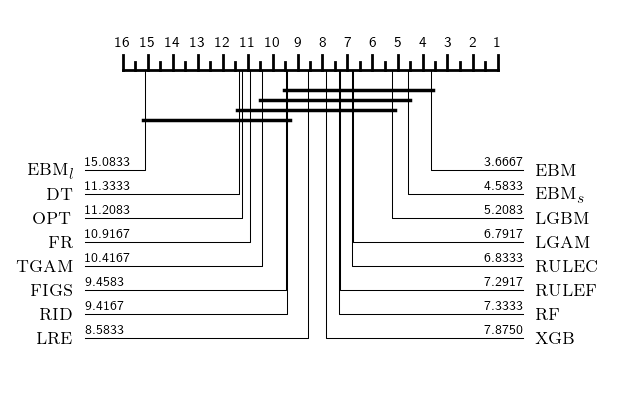

In [1025]:
import matplotlib.pyplot as plt
from aeon.visualisation import plot_critical_difference

plt.rcParams['text.usetex'] = True

rename_map = {
    'RuleCard': r'\textsc{rulec}',
    'ScoreCard': r'\textsc{rulec}',
    'ScoreCard2': 'RC2',
    'ScoreCard3': 'RC3',
    'EBM': r'\textsc{ebm}',
    'FIGS': r'\textsc{figs}',
    'TreeGAMCl': r'\textsc{tgam}',
    'fasterrisk': r'\textsc{fr}',
    'fasterriskBin': r'\textsc{fr}',
    'LogisticGAM': r'\textsc{lgam}',
    'ridge': r'\textsc{rid}',
    'log_reg': r'\textsc{lre}',
    #'EBM+LASSO': r'EBM-L',
    #'slimrisk': r'SLIM',
    #'Apriori+Log_reg': r'A-LR',
    'boley': r'\textsc{opt}',
    'apriori_log': r'\textsc{a-lre}',
    'apriori_ridge': r'\textsc{a-rid}',
    'rulefit': r'\textsc{rulef}',
    'RF': r'\textsc{rf}',
    'dt': r'\textsc{dt}',
    'lgbm': r'\textsc{lgbm}',
    'xgboost': r'\textsc{xgb}',
    'EBMLasso': r'\textsc{ebm}$_{l}$',
    'EBMSweep': r'\textsc{ebm}$_{s}$'
}

col_drop = [
    'apriori_log', 'apriori_ridge', 
    'fasterrisk',
    'ScoreCard', 'ScoreCard2', 'ScoreCard3'
]

df_pivot_noNAN = df_pivot.T

#df_pivot_noNAN = df_pivot.T.drop(columns=col_drop).T.dropna(axis=1).T
df_pivot_noNAN = df_pivot.fillna(.0).T.drop(columns=col_drop)

#display(df_pivot.T.drop(columns=col_drop).agg(['mean', 'std']))

display(df_pivot.T.drop(columns=col_drop))

#df_pivot.T.drop(columns=col_drop).agg(['mean', 'std']).to_excel('best_f1_score.xlsx')

plot_critical_difference(df_pivot_noNAN.values, 
                         [rename_map[x] for x in df_pivot_noNAN.columns], 
                         test='nemenyi', alpha=.1,
                         #width=5.2
                        )

#plt.tight_layout()
plt.savefig('cd_f1.svg', dpi=600)
plt.show()

In [54]:
df_best.accuracy

0      0.874349
1      0.430176
2      0.874512
3      0.866699
4      0.861328
         ...   
185    0.782123
186    0.798883
187    0.798883
188    0.770950
189    0.798883
Name: accuracy, Length: 190, dtype: float64

model_name,EBM,EBMLasso,EBMSweep,FIGS,LogisticGAM,RF,RuleCard,TreeGAMCl,boley,dt,fasterrisk,lgbm,log_reg,ridge,rulefit,xgboost
mean,0.841128,0.469220,0.839036,0.819447,0.830677,0.832911,0.832296,0.824646,0.808602,0.802301,0.717200,0.830400,0.779320,0.772029,0.825538,0.822812
std,0.086421,0.119793,0.087139,0.089787,0.094525,0.089105,0.093138,0.088431,0.095473,0.097860,0.174757,0.091811,0.101028,0.098451,0.098616,0.100431


model_name,EBM,EBMLasso,EBMSweep,FIGS,LogisticGAM,RF,RuleCard,TreeGAMCl,boley,dt,fasterrisk,lgbm,log_reg,ridge,rulefit,xgboost
dataset_name,,,,,,,,,,,,,,,,
adult,0.874349,0.430176,0.874512,0.866699,0.861328,0.847819,0.862467,0.866048,0.831543,0.858887,0.814616,0.876790,0.759928,0.780273,0.873210,0.875977
bank,0.937333,0.310633,0.937233,0.937100,0.936900,0.936533,0.935933,0.937133,0.931500,0.898633,NaN,0.935900,0.873900,0.775867,0.937467,0.936800
bankMarketing,0.772500,0.582500,0.772500,0.740000,0.770000,0.765000,0.765000,0.777500,0.720000,0.740000,0.500000,0.757500,0.727500,0.702500,0.745000,0.737500
breast,0.973684,0.596491,0.973684,0.912281,0.982456,0.973684,0.982456,0.921053,0.912281,0.912281,0.921053,0.964912,0.921053,0.929825,0.964912,0.973684
compass,0.734581,0.456687,0.733888,0.720721,0.724186,0.738046,0.723493,0.728344,0.724879,0.702703,NaN,0.732502,0.720028,0.717949,0.724186,0.728344
diabetes,0.766234,0.506494,0.766234,0.746753,0.740260,0.740260,0.753247,0.707792,0.733766,0.694805,0.590909,0.759740,0.740260,0.746753,0.720779,0.727273
german_credit,0.790000,0.400000,0.790000,0.765000,0.770000,0.805000,0.775000,0.775000,0.705000,0.690000,0.710000,0.750000,0.690000,0.670000,0.815000,0.715000
magic,0.785000,0.562500,0.785000,0.767500,0.755000,0.787500,0.760000,0.775000,0.737500,0.747500,0.670000,0.772500,0.712500,0.707500,0.720000,0.767500
mushroom,1.000000,0.668923,1.000000,0.998769,1.000000,1.000000,1.000000,0.998769,0.998769,1.000000,1.000000,1.000000,0.999385,0.998769,1.000000,0.998154


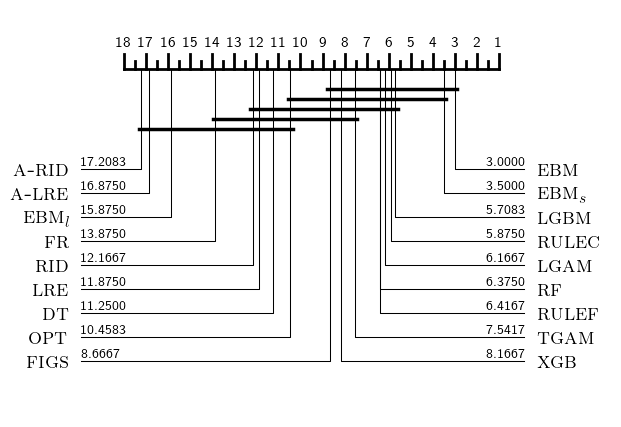

In [59]:
df_best = df.sort_values(by=['dataset_name', 'model_name', 'val_f1_score'], ascending=[False, False, False]).groupby(['dataset_name', 'model_name']).first().reset_index()
df_pivot = df_best.pivot(columns=['dataset_name'], index='model_name', values='accuracy')

col_drop = ['apriori_log', 'apriori_ridge', 'ScoreCard', 'ScoreCard2', 'ScoreCard3']

df_pivot_noNAN = df_pivot.T

#df_pivot_noNAN = df_pivot.T.drop(columns=col_drop).T.dropna(axis=1).T
df_pivot_noNAN = df_pivot.fillna(.0).T.drop(columns=['ScoreCard', 'ScoreCard2', 'ScoreCard3'])

display(df_pivot.T.drop(columns=col_drop).agg(['mean', 'std']))

display(df_pivot.T.drop(columns=col_drop))

df_pivot.T.drop(columns=col_drop).agg(['mean', 'std']).to_excel('best_accuracy.xlsx')

plot_critical_difference(df_pivot_noNAN.values, 
                         [rename_map[x] for x in df_pivot_noNAN.columns], 
                         test='nemenyi', alpha=.1,
                         #width=5.2
                        )

#plt.tight_layout()
#plt.savefig('cd_f1.png', dpi=600)
plt.show()

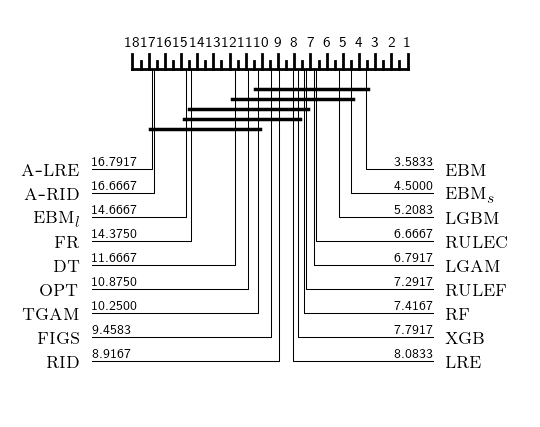

In [13]:
means = df_pivot_noNAN.mean(axis=0)

fig, ax = plot_critical_difference(
    df_pivot_noNAN.values,
    [rename_map[x] for x in df_pivot_noNAN.columns],
    test='nemenyi',
    alpha=.1,
    width=5.2,
)

texts = ax.findobj(match=plt.Text)

model_i = 0
for t in ax.texts:
    s = t.get_text()
    x, y = t.get_position()

    try:
        float(s)
        print(s, len(s), round(means[m], 5), sep='\t')
        if len(s) != 1:              # esclude i tick della scala
            m = df_pivot_noNAN.columns[model_i]
            t.set_text(f"{means[m]:.3f}")
            model_i += 1
    except:
        pass

plt.savefig('cd_f1_mean.png', dpi=600)
plt.show()

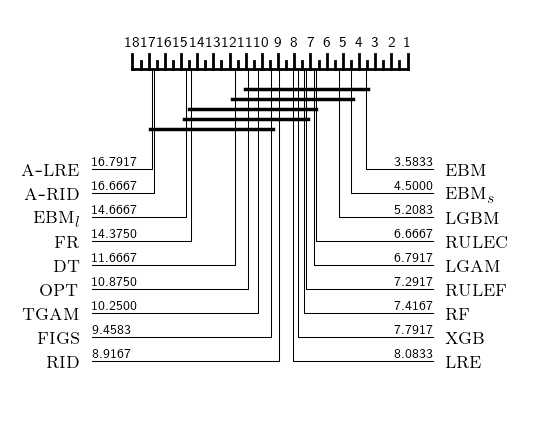

In [14]:
means = df_pivot_noNAN.mean(axis=0)
std = df_pivot_noNAN.std(axis=0)

fig, ax = plot_critical_difference(
    df_pivot_noNAN.values,
    [rename_map[x] for x in df_pivot_noNAN.columns],
    test='nemenyi',
    alpha=.05,
    width=5.2,
)

texts = ax.findobj(match=plt.Text)

model_i = 0
for t in ax.texts:
    s = t.get_text()
    x, y = t.get_position()

    try:
        float(s)
        print(s, len(s), round(means[m], 5), sep='\t')
        if len(s) != 1:              # esclude i tick della scala
            m = df_pivot_noNAN.columns[model_i]
            t.set_text(f"{means[m]:.2f}$\\pm${std[m]:.2f}")
            model_i += 1
    except:
        pass

plt.savefig('cd_f1_mean_std.png', dpi=600)
plt.show()

In [15]:
df_pivot_latex = df_pivot.copy().T
df_pivot_latex.columns = [rename_map[x] for x in df_pivot_latex.columns]

print(df_pivot_latex[rename_map.values()].round(3).to_latex(float_format="%.3f"))

df_pivot_latex[rename_map.values()].round(3)

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & \textsc{rulec} & \textsc{rulec} & \textsc{rulec} & \textsc{rulec} & RC2 & RC3 & \textsc{ebm} & \textsc{figs} & \textsc{tgam} & \textsc{fr} & \textsc{lgam} & \textsc{rid} & \textsc{lre} & \textsc{opt} & \textsc{a-lre} & \textsc{a-rid} & \textsc{rulef} & \textsc{rf} & \textsc{dt} & \textsc{lgbm} & \textsc{xgb} & \textsc{ebm}$_{l}$ & \textsc{ebm}$_{s}$ \\
dataset_name &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
adult & 0.692 & 0.696 & 0.692 & 0.696 & 0.696 & 0.696 & 0.727 & 0.702 & 0.683 & 0.544 & 0.699 & 0.658 & 0.640 & 0.636 & NaN & NaN & 0.728 & 0.678 & 0.679 & 0.734 & 0.732 & 0.465 & 0.726 \\
bank & 0.226 & 0.246 & 0.226 & 0.246 & 0.246 & 0.246 & 0.300 & 0.259 & 0.243 & NaN & 0.273 & 0.231 & 0.382 & 0.037 & 0.000 & 0.125 & 0.277 & 0.285 & 0.264 & 0.305 & 0.315 & 0.159 & 0.299 \\
bankMarketing & 0.763 & 0.748 & 0.763 & 0.748 & 0.748 & 0.748 & 0.771 & 0.735 & 0.775 & 0.000 & 0.764 & 0.689 & 0.712 

,\textsc{rulec},\textsc{rulec},\textsc{rulec},\textsc{rulec},RC2,RC3,\textsc{ebm},\textsc{figs},\textsc{tgam},\textsc{fr},...,\textsc{opt},\textsc{a-lre},\textsc{a-rid},\textsc{rulef},\textsc{rf},\textsc{dt},\textsc{lgbm},\textsc{xgb},\textsc{ebm}$_{l}$,\textsc{ebm}$_{s}$
dataset_name,,,,,,,,,,,,,,,,,,,,,
adult,0.692,0.696,0.692,0.696,0.696,0.696,0.727,0.702,0.683,0.544,...,0.636,NaN,NaN,0.728,0.678,0.679,0.734,0.732,0.465,0.726
bank,0.226,0.246,0.226,0.246,0.246,0.246,0.300,0.259,0.243,NaN,...,0.037,0.000,0.125,0.277,0.285,0.264,0.305,0.315,0.159,0.299
bankMarketing,0.763,0.748,0.763,0.748,0.748,0.748,0.771,0.735,0.775,0.000,...,0.720,0.667,0.667,0.740,0.763,0.714,0.749,0.742,0.704,0.771
breast,0.976,0.976,0.976,0.976,0.976,0.976,0.963,0.875,0.886,0.883,...,0.886,0.538,0.000,0.950,0.963,0.872,0.950,0.963,0.646,0.963
compass,0.659,NaN,0.659,NaN,NaN,NaN,0.671,0.650,0.655,NaN,...,0.653,0.621,0.621,0.661,0.668,0.628,0.667,0.667,0.623,0.671
diabetes,0.627,0.627,0.627,0.627,0.627,0.627,0.647,0.614,0.516,0.618,...,0.586,0.519,0.519,0.527,0.583,0.373,0.648,0.596,0.582,0.647
german_credit,0.563,0.585,0.563,0.585,0.585,0.585,0.625,0.591,0.505,0.147,...,0.504,0.462,0.462,0.654,0.589,0.031,0.576,0.496,0.496,0.618
magic,0.754,0.752,0.754,0.752,0.752,0.752,0.775,0.744,0.767,0.637,...,0.730,0.667,0.667,0.711,0.775,0.732,0.764,0.753,0.696,0.775
mushroom,1.000,0.998,1.000,0.998,0.998,0.998,1.000,0.999,0.999,1.000,...,0.999,NaN,NaN,1.000,1.000,1.000,1.000,0.998,0.744,1.000


In [16]:
# complessità

filename = df_best[df_best.model_name == 'EBM'].filename.values[0].replace('.csv', '.pkl')

with open(filename, 'rb') as f:
    clf = pickle.load(f)

filename

'res/adult/EBM/d7225a3bd04e76ac021b87526753f599.pkl'

In [17]:
len(clf.term_importances())

136

In [18]:
df_best = df.sort_values(by=['dataset_name', 'model_name', 'val_f1_score', 'fit_time'], ascending=[False, False, False, True])\
    .groupby(['dataset_name', 'model_name']).first().reset_index()
df_best = df_best[df_best.model_name != 'ScoreCard2']
df_best = df_best[df_best.model_name != 'RuleCard']

df_best.pivot(columns=['dataset_name'], index='model_name', values='predict_time').agg(['mean', 'std'], axis=1)

,mean,std
model_name,,
EBM,0.005609,0.007717
EBMLasso,0.004728,0.008073
EBMSweep,0.010609,0.022534
FIGS,0.024013,0.049466
LogisticGAM,0.153136,0.264920
RF,0.230200,0.315758
ScoreCard,0.008438,0.009387
ScoreCard3,0.004286,0.003944
TreeGAMCl,0.484430,0.594370


In [19]:
def navigate_figs(node):
    if node.left is None:
        return [str(node)]
    return navigate_figs(node.left) + navigate_figs(node.right)

def get_complexity(model_name, filename):
    if model_name in ['fasterrisk', 'RuleCard', 'ScoreCard', 'RuleCard2']:
        return None, None
    
    with open(filename, 'rb') as f:
        clf = pickle.load(f)

    if model_name == 'EBM':
        locale = (clf.best_iteration_ * len(clf.term_features_)).sum()
        globale = 2*locale
    elif model_name == 'TreeGAMCl':
        locale = len(clf.estimators_)
        globale = np.sum([est.get_n_leaves() for est in clf.estimators_])
    elif model_name == 'FIGS':
        locale = len(clf.trees_)
        globale = np.sum([len(navigate_figs(tree)) for tree in clf.trees_])
    elif model_name in ['ridge', 'log_reg']:
        locale = np.sum(clf.coef_ > 10**-6)
        globale = locale
    elif model_name == 'LogisticGAM':
        locale = np.sum(clf.coef_[:-1]>= 10^-6)
        globale = locale
    else:
        return np.nan, np.nan

    return locale, globale

In [20]:
locale, globale = [], []

for model_name, filename in tqdm(df_best[['model_name', 'filename']].values):
    try:
        l, g = get_complexity(model_name, filename.replace('.csv', '.pkl'))
    except:
        l, g = np.nan, np.nan
    locale.append(l)
    globale.append(g)

  0%|          | 0/218 [00:00<?, ?it/s]

In [21]:
df_best_compl = df_best.copy()
df_best_compl['local_exp'] = locale
df_best_compl['global_exp'] = globale
df_best_compl = df_best_compl[df_best_compl.model_name != 'fasterrisk']

df_best_compl = df_best_compl[['dataset_name', 'model_name', 'local_exp', 'global_exp']]\
    .sort_values(['model_name', 'dataset_name'])

df_best_compl.to_excel('df_best_compl.xlsx')

df_best_compl

,dataset_name,model_name,local_exp,global_exp
0,adult,EBM,191002344.0,382004688.0
19,bank,EBM,11707760.0,23415520.0
39,bankMarketing,EBM,961996.0,1923992.0
60,breast,EBM,2876940.0,5753880.0
81,compass,EBM,9801012.0,19602024.0
...,...,...,...,...
160,magic,xgboost,NaN,NaN
179,mushroom,xgboost,NaN,NaN
200,taiwan_credit,xgboost,NaN,NaN
219,telco,xgboost,NaN,NaN


In [22]:
df_best_compl = df_best.copy()
df_best_compl['local_exp'] = locale
df_best_compl['global_exp'] = globale
df_best_compl = df_best_compl[df_best_compl.model_name != 'fasterrisk']

df_best_compl[
    (df_best_compl.dataset_name == 'bank')
    & (df_best_compl.model_name == 'ScoreCard')
].filename.values

array(['res/bank/ScoreCard/2e94adc693dc1bde1053c1c63a4d6a1a.csv'],
      dtype=object)

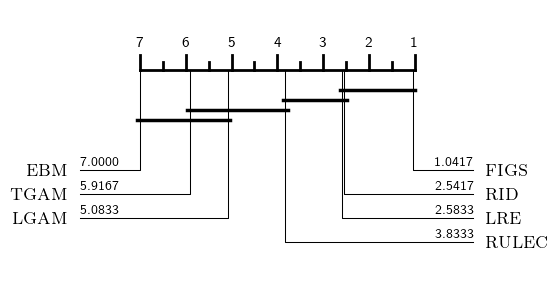

In [23]:
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)

df_best_compl = pd.read_excel('df_best_compl2.xlsx', index_col=0)
df_best_compl = df_best_compl.pivot(columns='dataset_name', index='model_name', values='local_exp').T.fillna(10000000)

plot_critical_difference(df_best_compl.values, [rename_map[x] for x in df_best_compl.columns], test='nemenyi', 
                         alpha=.1, lower_better=True, width=5.2)

plt.savefig('cd_complexity_local.png', dpi=600)


In [24]:
pd.read_excel('df_best_compl2.xlsx', index_col=0)\
    .pivot(columns='dataset_name', index='model_name', values='local_exp').T.fillna(10000000)

model_name,EBM,FIGS,LogisticGAM,ScoreCard,TreeGAMCl,log_reg,ridge
dataset_name,,,,,,,
adult,477243584.0,7.0,680.0,42.0,3400.0,13.0,20.0
bank,11240080.0,5.0,195.0,12.0,1000.0,6.0,6.0
bankMarketing,3762360.0,4.0,140.0,59.0,700.0,4.0,5.0
breast,4608420.0,1.0,600.0,13.0,1680.0,23.0,19.0
compass,872466.0,1.0,279.0,31.0,1400.0,8.0,7.0
diabetes,358536.0,3.0,160.0,11.0,800.0,6.0,6.0
german_credit,31119088.0,4.0,520.0,52.0,1898.0,12.0,11.0
magic,8307600.0,3.0,200.0,47.0,1000.0,5.0,6.0
mushroom,99856736.0,1.0,10000000.0,141.0,11200.0,55.0,49.0


In [25]:
pd.read_excel('df_best_compl2.xlsx', index_col=0)\
    .pivot(columns='dataset_name', index='model_name', values='global_exp').T.fillna(10000000)

model_name,EBM,FIGS,LogisticGAM,ScoreCard,TreeGAMCl,log_reg,ridge
dataset_name,,,,,,,
adult,954487168.0,55.0,680.0,302.0,7500.0,13.0,20.0
bank,22480160.0,17.0,195.0,45.0,3000.0,6.0,6.0
bankMarketing,7524720.0,28.0,140.0,300.0,2100.0,4.0,5.0
breast,9216840.0,13.0,600.0,170.0,5040.0,23.0,19.0
compass,1744932.0,7.0,279.0,70.0,3900.0,8.0,7.0
diabetes,717072.0,9.0,160.0,44.0,2400.0,6.0,6.0
german_credit,62238176.0,28.0,520.0,229.0,4526.0,12.0,11.0
magic,16615200.0,27.0,200.0,253.0,3000.0,5.0,6.0
mushroom,199713472.0,14.0,10000000.0,689.0,22300.0,55.0,49.0


name:  1.0417
1.0417 _ None
name:  \textsc{figs}
name:  \textsc{rid}
name:  \textsc{lre}
name:  \textsc{rulec}
name:  \textsc{lgam}
name:  \textsc{tgam}
name:  \textsc{ebm}


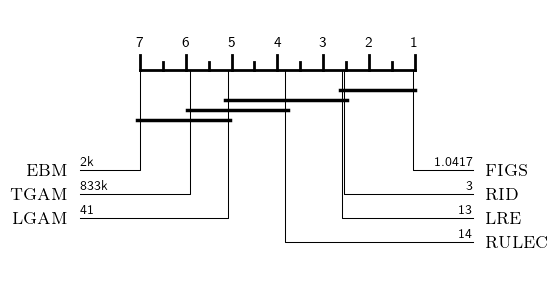

In [26]:
means = dict(df_best_compl.mean(axis=0))
means = {rename_map[k]: v for k, v in means.items()}
std = df_best_compl.std(axis=0)

fig, ax = plot_critical_difference(df_best_compl.values, [rename_map[x] for x in df_best_compl.columns], test='nemenyi', 
                         alpha=.05, lower_better=True, width=5.2)

texts = ax.findobj(match=plt.Text)

model_i = 0
name=None
for t in ax.texts:
    s = t.get_text()
    x, y = t.get_position()

    try:
        float(s)
        if len(s) != 1:              # esclude i tick della scala
            #m = df_best_compl.columns[model_i]
            #t.set_text(f"{means[m]:.2f}$\\pm${std[m]:.2f}")
            num_str = f'{means[name]:.0f}'
            if len(num_str) > 6:
                num_str = num_str[:-6]+'M'
            elif len(num_str) > 3:
                num_str = num_str[:-3]+'k'
            t.set_text(num_str)
            model_i += 1
    except Exception as e:
        name = s#[:-1].split('{')[-1]
        print('name: ', name)
        if 'convert string to float' not in str(e):
            print(t.get_text(),'_', e)

plt.savefig('cd_complexity_local_mean.png', dpi=600)
plt.show()

name:  1.0417
1.0417 _ None
name:  \textsc{figs}
name:  \textsc{rid}
name:  \textsc{lre}
name:  \textsc{rulec}
name:  \textsc{lgam}
name:  \textsc{tgam}
name:  \textsc{ebm}


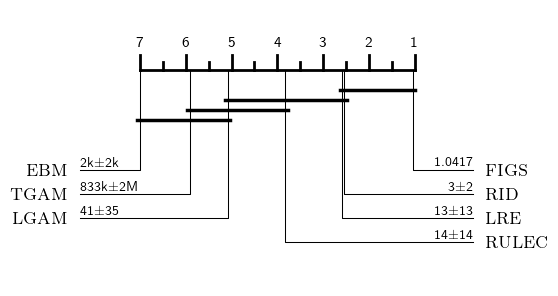

In [27]:
means = dict(df_best_compl.mean(axis=0))
means = {rename_map[k]: v for k, v in means.items()}
std = dict(df_best_compl.std(axis=0))
std = {rename_map[k]: v for k, v in std.items()}

fig, ax = plot_critical_difference(df_best_compl.values, [rename_map[x] for x in df_best_compl.columns], test='nemenyi', 
                         alpha=.05, lower_better=True, width=5.2)

texts = ax.findobj(match=plt.Text)

model_i = 0
name=None
for t in ax.texts:
    s = t.get_text()
    x, y = t.get_position()

    try:
        float(s)
        if len(s) != 1:              # esclude i tick della scala
            #m = df_best_compl.columns[model_i]
            #t.set_text(f"{means[m]:.2f}$\\pm${std[m]:.2f}")
            num_str = f'{means[name]:.0f}'
            if len(num_str) > 6:
                num_str = num_str[:-6]+'M'
            elif len(num_str) > 3:
                num_str = num_str[:-3]+'k'
            
            std_str = f'{std[name]:.0f}'
            if len(std_str) > 6:
                std_str = std_str[:-6]+'M'
            elif len(std_str) > 3:
                std_str = std_str[:-3]+'k'
            t.set_text(num_str+r'$\pm$'+std_str)
            model_i += 1
    except Exception as e:
        name = s#[:-1].split('{')[-1]
        print('name: ', name)
        if 'convert string to float' not in str(e):
            print(t.get_text(),'_', e)

plt.savefig('cd_complexity_local_mean_std.png', dpi=600)
plt.show()

In [28]:
df_best_compl.mean(axis=0)

model_name
EBM            5.633964e+07
FIGS           3.000000e+00
LogisticGAM    8.336828e+05
ScoreCard      4.108333e+01
TreeGAMCl      2.514833e+03
log_reg        1.366667e+01
ridge          1.300000e+01
dtype: float64

In [29]:
df_best.pivot(columns='dataset_name', index='model_name', values='f1_score').T.fillna(0).mean(axis=0)

model_name
EBM              0.694729
EBMLasso         0.546537
EBMSweep         0.690689
FIGS             0.656354
LogisticGAM      0.674829
RF               0.670794
ScoreCard        0.612852
ScoreCard3       0.612852
TreeGAMCl        0.639930
apriori_log      0.310474
apriori_ridge    0.331599
boley            0.627177
dt               0.584640
fasterrisk       0.430073
lgbm             0.680029
log_reg          0.659135
ridge            0.656177
rulefit          0.665969
xgboost          0.668700
dtype: float64

KeyError: 'EBMLasso'

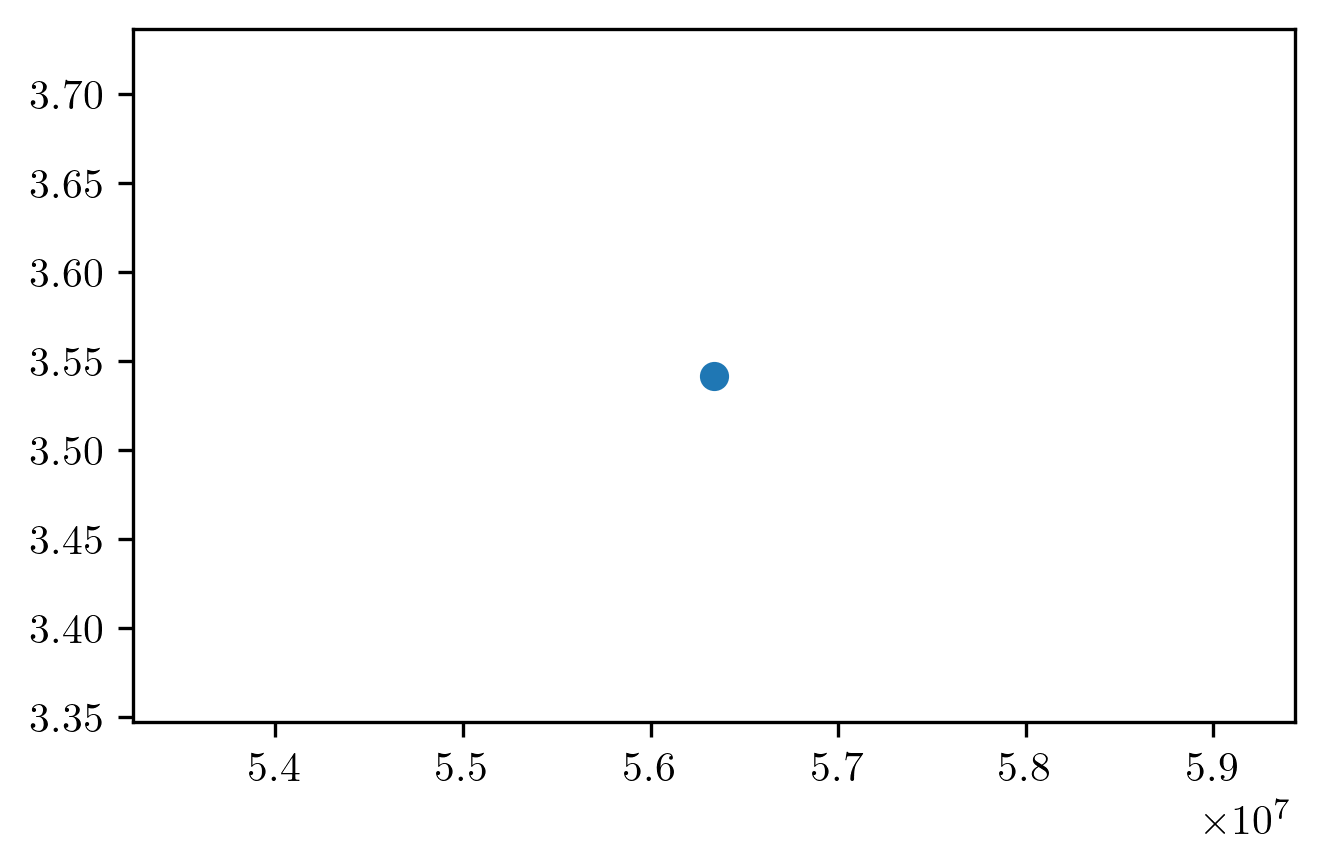

In [30]:
plt.figure(figsize=(5, 3), dpi=300)

models = df_best.model_name.unique()

# Rank dei modelli per ogni dataset (più alto è meglio)
f1_ranks = df_best.pivot(columns='dataset_name', index='model_name', values='f1_score').fillna(.0).rank(ascending=False).T
f1_rank_mean = f1_ranks.mean(axis=0)

# Complessità rimane la stessa media
compl_mean = df_best_compl.mean(axis=0)

for model in models:
    if model == 'fasterrisk':
        continue
    plt.scatter([compl_mean[model]], [f1_rank_mean[model]], label=rename_map[model])

plt.gca().xaxis.set_inverted(True)
plt.gca().yaxis.set_inverted(True)
plt.xlabel('Local Complexity', fontsize=14)
plt.ylabel('F1-score rank (rank)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xscale('log')

plt.legend(ncol=7, fontsize=12,
           handlelength=.002, handletextpad=0.4, columnspacing=.83,
           bbox_to_anchor=(0.48, .96), loc='lower center', frameon=False)

plt.tight_layout()
plt.savefig('scatter_rank.png')
plt.show()

In [39]:
df_best = df.sort_values(by=['dataset_name', 'model_name', 'val_f1_score', 'predict_time'], ascending=[False, False, False, True]).groupby(['dataset_name', 'model_name']).first().reset_index()
df_best = df_best[df_best.model_name != 'ScoreCard2']
df_best = df_best[df_best.model_name != 'RuleCard']

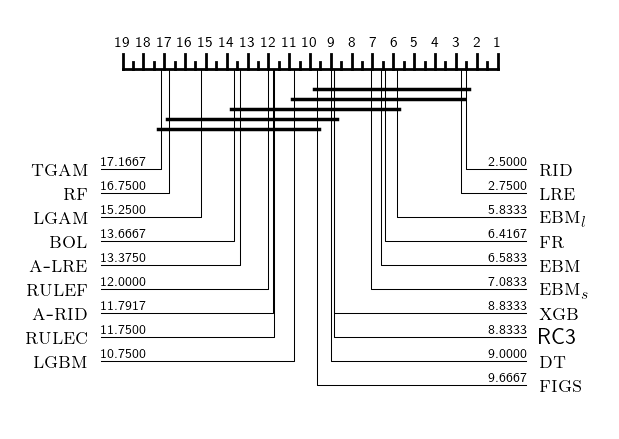

In [40]:
df_pivot = df_best.pivot(columns=['dataset_name'], index='model_name', values='predict_time')

df_pivot_noNAN = df_pivot.fillna(100000000).T

plot_critical_difference(df_pivot_noNAN.values, [rename_map[x] for x in df_pivot_noNAN.columns], test='nemenyi', alpha=.05, lower_better=True)

#plt.tight_layout()
plt.savefig('cd_time.png', dpi=600)
plt.show()

In [12]:
df_pivot_latex = df_pivot.copy().T
df_pivot_latex.columns = [rename_map[x] for x in df_pivot_latex.columns]

print(df_pivot_latex[rename_map.values()].round(5).to_latex(float_format="%.3f"))

df_pivot_latex[rename_map.values()].round(4)

\begin{tabular}{lrrrrrrrrr}
\toprule
 & RC & RC & EBM & FIGS & TG & FR & LG & RID & LR \\
dataset_name &  &  &  &  &  &  &  &  &  \\
\midrule
adult & 0.018 & 0.018 & 0.017 & 0.079 & 1.278 & 0.002 & 0.402 & 0.001 & 0.001 \\
bank & 0.029 & 0.029 & 0.027 & 0.165 & 0.683 & NaN & 0.897 & 0.001 & 0.005 \\
bankMarketing & 0.003 & 0.003 & 0.001 & 0.002 & 0.034 & 0.000 & 0.005 & 0.000 & 0.000 \\
breast & 0.001 & 0.001 & 0.001 & 0.000 & 0.111 & 0.000 & 0.013 & 0.000 & 0.000 \\
compass & 0.001 & 0.001 & 0.001 & 0.002 & 0.134 & 0.001 & 0.022 & 0.000 & 0.000 \\
diabetes & 0.001 & 0.001 & 0.000 & 0.001 & 0.037 & 0.000 & 0.004 & 0.000 & 0.000 \\
german_credit & 0.004 & 0.004 & 0.001 & 0.001 & 0.129 & 0.000 & 0.016 & 0.000 & 0.000 \\
magic & 0.005 & 0.005 & 0.002 & 0.002 & 0.063 & 0.000 & 0.008 & 0.000 & 0.000 \\
mushroom & 0.013 & 0.013 & 0.004 & 0.005 & 3.216 & 0.001 & NaN & 0.001 & 0.001 \\
taiwan_credit & 0.006 & 0.006 & 0.011 & 0.016 & 0.686 & 0.001 & 0.219 & 0.000 & 0.001 \\
telco & 0.004 & 0.00

,RC,RC,EBM,FIGS,TG,FR,LG,RID,LR
dataset_name,,,,,,,,,
adult,0.0182,0.0182,0.0165,0.0786,1.2780,0.0015,0.4023,0.0009,0.0011
bank,0.0288,0.0288,0.0275,0.1650,0.6827,NaN,0.8969,0.0014,0.0048
bankMarketing,0.0027,0.0027,0.0008,0.0023,0.0342,0.0003,0.0053,0.0001,0.0002
breast,0.0012,0.0012,0.0009,0.0003,0.1114,0.0005,0.0128,0.0001,0.0003
compass,0.0009,0.0009,0.0007,0.0021,0.1344,0.0006,0.0215,0.0001,0.0003
diabetes,0.0015,0.0015,0.0003,0.0009,0.0372,0.0004,0.0041,0.0001,0.0003
german_credit,0.0035,0.0035,0.0011,0.0011,0.1294,0.0005,0.0162,0.0001,0.0003
magic,0.0046,0.0046,0.0017,0.0019,0.0634,0.0005,0.0077,0.0001,0.0002
mushroom,0.0127,0.0127,0.0043,0.0048,3.2164,0.0012,NaN,0.0007,0.0009


In [13]:
df_pivot_latex[list(rename_map.values())[1:]].agg(['mean', 'std']).round(4)

,RC,EBM,FIGS,TG,FR,LG,RID,LR
mean,0.0071,0.0056,0.0235,0.5884,0.0007,0.1524,0.0004,0.0008
std,0.0086,0.0085,0.0497,0.9166,0.0004,0.2770,0.0004,0.0013


In [27]:
group_cols = ['learning_rate', 'use_fast', 'reuse_features', 'top_k_features']
score_cols = ['f1_score', 'n_rules']

df_rulecard = df[df.model_name == 'ScoreCard']

df_best = df_rulecard.sort_values(['dataset_name']+group_cols+score_cols, ascending=[False]*6+[True]).groupby(['dataset_name']+group_cols).first().reset_index()
#.groupby(group_cols)[score_cols].mean().reset_index().pivot(columns='top_k_features', index=group_cols[:-1]).round(3)

df_best

,dataset_name,learning_rate,use_fast,reuse_features,top_k_features,patience,max_depth,max_n_iter,feature_order,recompute_feature_order,...,min_impurity_decrease,max_features,max_bins,max_interaction_bins,interactions,validation_size,penalty,C,l1_ratio,dual
0,adult,0.3,False,False,3,15.0,1.0,500.0,feature_importance,False,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
1,adult,0.3,False,False,5,15.0,1.0,500.0,feature_importance,True,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
2,adult,0.3,False,False,inf,15.0,1.0,100.0,feature_importance,True,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
3,adult,0.3,False,False,sqrt,15.0,3.0,100.0,feature_importance,False,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
4,adult,0.3,False,True,3,15.0,2.0,100.0,feature_importance,False,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,titanic,1.0,True,False,sqrt,15.0,2.0,500.0,random,False,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
571,titanic,1.0,True,True,3,15.0,3.0,100.0,feature_importance,True,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
572,titanic,1.0,True,True,5,15.0,3.0,100.0,feature_importance,False,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None
573,titanic,1.0,True,True,inf,15.0,3.0,100.0,feature_importance,False,...,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,None


In [28]:
df.columns

Index(['learning_rate', 'patience', 'max_depth', 'max_n_iter', 'feature_order',
       'recompute_feature_order', 'reuse_features', 'use_fast',
       'top_k_features', 'n_jobs', 'feature_importance_estimator',
       'dataset_name', 'model_name', 'cv_fit_time', 'cv_predict_time',
       'val_accuracy', 'val_balanced_accuracy', 'val_f1_score', 'val_f1_micro',
       'val_f1_macro', 'val_f1_weighted', 'val_precision_score',
       'val_precision_micro', 'val_precision_macro', 'val_precision_weighted',
       'val_recall_score', 'val_recall_micro', 'val_recall_macro',
       'val_recall_weighted', 'val_roc_macro', 'val_roc_micro',
       'val_roc_weighted', 'val_average_precision_macro',
       'val_average_precision_micro', 'val_average_precision_weighted',
       'fit_time', 'predict_time', 'accuracy', 'balanced_accuracy', 'f1_score',
       'f1_micro', 'f1_macro', 'f1_weighted', 'precision_score',
       'precision_micro', 'precision_macro', 'precision_weighted',
       'recall_score'

In [29]:
import h5py
import pickle
from sklearn.metrics import f1_score
from scipy.special import expit

def load_h5(filename):
    data = {}

    with h5py.File(filename, 'r') as f:
        data['X_train'] = f['X_train'][:]
        data['y_train'] = f['y_train'][:]
        data['X_test'] = f['X_test'][:]
        data['y_test'] = f['y_test'][:]

        if 'y_pred_proba' in f:
            data['y_pred_proba'] = f['y_pred_proba'][:]
        else:
            data['y_pred_proba'] = None

        data['res'] = dict(f.attrs)

    return data

def predict_proba(self, X:np.ndarray, min_sup=0):
    scores = np.zeros((X.shape[0],))
    for base_points, rules, support, points in self.scorecard:
        if min_sup > support:
            continue
        scores[self._get_activation(X, rules)] += points
    scores += self.scorecard[0][0]  # basepoints
    return expit((scores - self.offset) / self.factor)

def predict(self, X, min_sup=0):
    return np.vectorize(lambda x: self.classes[x])((predict_proba(self, X, min_sup) > .5).astype(int))

def exp_score(filename):
    s = pickle.load(open(filename.replace('.csv', '.pkl'), 'rb'))
    data = load_h5(filename.replace('.csv', '.h5').replace('/ScoreCard/', '/RuleCard/'))
    X = data['X_train']
    #X = data['X_test']
    #y_train = data['y_train']
    #y_test = data['y_test']
    
    scorecard = s.scorecard
    n_rules = len(scorecard)
    n_feature_used = set()
    rule_activations = []
    rule_scores = []
    rule_support = []
    
    for _, rules, supp, score in scorecard:
        rule_scores += [score]
        rule_support += [supp]
        for f_idx, thr, comp in rules:
            n_feature_used |= {int(f_idx)}
        rule_activations.append(s._get_activation(X, rules))

    rule_support = np.array(rule_support)

    
    rule_activated, performance_supp, performance_supp_test = [], [], []
    if n_rules != 0:
        rule_activated = [np.mean(np.sum(np.vstack(rule_activations)[rule_support>x], axis=0)) for x in range(max(rule_support))]
        performance_supp = [f1_score(y_pred=predict(s, data['X_train'], x), y_true=data['y_train']) for x in range(max(rule_support))]
        performance_supp_test = [f1_score(y_pred=predict(s, data['X_test'], x), y_true=data['y_test']) for x in range(max(rule_support))]

    return {
        'n_rules': n_rules,
        'n_feature_used': n_feature_used,
        'rule_activations': rule_activations,
        'rule_scores': np.array(rule_scores),
        'rule_support': np.array(rule_support),
        'dataset': data,
        'rule_activated': rule_activated,
        'performance_supp': performance_supp,
        'performance_supp_test': performance_supp_test
    }

In [30]:
from multiprocessing import Pool
from tqdm.notebook import tqdm
import os, pickle

if os.path.exists("exp.pkl"):
    exp = pickle.load(open("exp.pkl", "rb"))
else:
    exp = {}

filenames = df_best.filename.unique()
todo = [f for f in filenames if f not in exp]

print(len(todo), flush=True)

with Pool(1000) as p:
    scores = list(tqdm(p.imap(exp_score, todo), total=len(todo)))

exp |= dict(zip(todo, scores))

pickle.dump(exp, open("exp.pkl", "wb"))

0


Exception ignored in: <function _releaseLock at 0x7967e821c400>
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 243, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 

KeyboardInterrupt


KeyboardInterrupt



In [257]:
#pickle.dump(exp, open('exp.pkl', 'wb'))
exp = pickle.load(open('exp.pkl', 'rb'))

In [31]:
def plot_support(rule_activated, performance_supp, performance_supp_test):
    fig, ax1 = plt.subplots()
    
    ax1.set_xlabel('min_support')
    
    l1, = ax1.plot(rule_activated, color="tab:blue", label="rule_activated")
    ax1.set_ylabel("rule_activated", color="tab:blue")
    
    ax2 = ax1.twinx()
    l2, = ax2.plot(performance_supp, color="tab:red", label="f1-score")
    l3, = ax2.plot(performance_supp_test, color="tab:pink", label="f1-score_val")
    ax2.set_ylabel("f1-score", color="tab:red")
    
    ax1.legend(handles=[l1, l2, l3], loc="upper right")

    return fig, ax1, ax2

n_rules_at_thr = []
f1_train_at_thr = []
f1_test_at_thr = []
supp_at_thr = []
rules_at_thr = []

for k in tqdm(df_best.filename):
    el = exp[k]
    rule_activated = el['rule_activated']
    performance_supp = np.array(el['performance_supp'])
    performance_supp_test = el['performance_supp_test']
    
    if el['n_rules'] == 0 or len(np.unique(performance_supp)) == 1:
        n_rules_at_thr.append(np.nan)
        f1_train_at_thr.append(np.nan)
        f1_test_at_thr.append(np.nan)
        supp_at_thr.append(np.nan)
        rules_at_thr.append(np.nan)
        continue

    perc = .05
    threshold = performance_supp[0] * (1 - perc)
    pos_perc = np.where(np.array(performance_supp) >= threshold)[0][-1]
    
    n_rules_at_thr.append(rule_activated[pos_perc])
    f1_train_at_thr.append(performance_supp[pos_perc])
    f1_test_at_thr.append(performance_supp_test[pos_perc])
    supp_at_thr.append(pos_perc)
    s = pickle.load(open(k.replace('.csv', '.pkl'), 'rb'))
    rules_at_thr.append(np.sum(np.array([supp for _, _, supp, _ in s.scorecard])>1))
    #print(pos_perc, performance_supp.shape, rule_activated[pos_perc], rule_activated[0])    
    #fig, ax1, ax2 = plot_support(rule_activated, performance_supp, performance_supp_test)
    #ax1.scatter([pos_perc], [rule_activated[pos_perc]], c='tab:red')
    #plt.title(k)
    #plt.show()
    

  0%|          | 0/575 [00:00<?, ?it/s]

In [32]:
df_best.filename[0]

'res/adult/ScoreCard/8c6c2fbbdbd8c6db1ac803f0fbaaf3c6.csv'

In [34]:
import pickle

n_it = []
for f in tqdm(df_best[df_best.model_name == 'ScoreCard'].filename):
    f = f.replace('/ScoreCard/', '/RuleCard/')[:-4]+'.pkl'
    with open(f, 'rb') as file:
        m = pickle.load(file)
    n_it.append(len(m.estimators_))

  0%|          | 0/575 [00:00<?, ?it/s]

In [35]:
df_best['activated_rules'] = n_rules_at_thr
df_best['f1_train_at_thr'] = f1_train_at_thr
df_best['f1_test_at_thr'] = f1_test_at_thr
df_best['supp_at_thr'] = supp_at_thr
df_best['total_rules'] = rules_at_thr
df_best['n_iter'] = n_it

In [36]:
score_cols2 = ['f1_test_at_thr', 'predict_time', 'fit_time', 'n_iter']#'activated_rules', 'total_rules']

df_best.groupby(group_cols)[score_cols2].mean().reset_index().pivot(columns='top_k_features', index=group_cols[:-1]).round(3)

f1_test_at_thr                       \
top_k_features                                     3      5    inf   sqrt   
learning_rate use_fast reuse_features                                       
0.3           False    False                   0.538  0.537  0.599  0.520   
                       True                    0.586  0.626  0.669  0.583   
              True     False                   0.618  0.546  0.685  0.675   
                       True                    0.571  0.616  0.706  0.547   
0.5           False    False                   0.531  0.507  0.585  0.540   
                       True                    0.583  0.580  0.674  0.604   
              True     False                   0.443  0.552  0.707  0.560   
                       True                    0.592  0.623  0.708  0.559   
1.0           False    False                   0.393  0.470  0.616  0.527   
                       True                    0.529  0.553  0.669  0.522   
              True     False                   0.545  0.548  0.704  0.434   
                       True                    0.617  0.634  0.688  0.599   

                                      predict_time                       \
top_k_features                                   3      5    inf   sqrt   
learning_rate use_fast reuse_features                                     
0.3           False    False                 0.003  0.004  0.001  0.004   
                       True                  0.021  0.008  0.007  0.008   
              True     False                 0.005  0.001  0.005  0.001   
                       True                  0.015  0.005  0.007  0.004   
0.5           False    False                 0.001  0.002  0.001  0.002   
                       True                  0.005  0.010  0.007  0.007   
              True     False                 0.004  0.001  0.005  0.001   
                       True                  0.008  0.004  0.008  0.004   
1.0           False    False                 0.002  0.004  0.001  0.002   
                       True                  0.002  0.003  0.006  0.003   
              True     False                 0.003  0.001  0.004  0.001   
                       True                  0.004  0.004  0.004  0.005   

                                      fit_time                              \
top_k_features                               3        5       inf     sqrt   
learning_rate use_fast reuse_features                                        
0.3           False    False             5.629   21.424    43.663    7.201   
                       True            209.687  328.928   105.621  300.962   
              True     False            28.905   46.645   688.387   36.567   
                       True            304.759  249.291  1017.021  425.380   
0.5           False    False            11.860   22.139    13.940   18.261   
                       True            198.760  276.590   534.648  170.580   
              True     False            29.422   27.597   628.997   35.984   
                       True            265.085  288.467   758.928  391.429   
1.0           False    False            11.235   24.243    55.844   12.789   
                       True            142.871  139.259    88.711  143.175   
              True     False            36.235   27.414   365.373   18.087   
                       True            152.309  161.375   396.388  215.009   

                                        n_iter                             
top_k_features                               3        5      inf     sqrt  
learning_rate use_fast reuse_features                                      
0.3           False    False             4.833    6.333   21.167    6.250  
                       True            186.250  195.167  278.417  230.750  
              True     False             7.667   13.167  124.000    8.667  
                       True            167.167  149.333  183.000  244.417  
0.5           False    False             4.083    6.1

In [40]:
score_cols2 = ['n_iter']#'activated_rules', 'total_rules']

print(df_best.groupby(group_cols)[score_cols2].mean().reset_index().pivot(columns='top_k_features', index=group_cols[:-1]).round(3).T.round(1).to_latex(float_format="%.1f"))

\begin{tabular}{llrrrrrrrrrrrr}
\toprule
 & learning_rate & \multicolumn{4}{r}{0.300000} & \multicolumn{4}{r}{0.500000} & \multicolumn{4}{r}{1.000000} \\
 & use_fast & \multicolumn{2}{r}{False} & \multicolumn{2}{r}{True} & \multicolumn{2}{r}{False} & \multicolumn{2}{r}{True} & \multicolumn{2}{r}{False} & \multicolumn{2}{r}{True} \\
 & reuse_features & False & True & False & True & False & True & False & True & False & True & False & True \\
 & top_k_features &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{n_iter} & 3 & 4.8 & 186.2 & 7.7 & 167.2 & 4.1 & 189.0 & 8.0 & 135.3 & 4.5 & 128.0 & 8.5 & 100.1 \\
 & 5 & 6.3 & 195.2 & 13.2 & 149.3 & 6.2 & 211.2 & 12.4 & 167.3 & 6.2 & 147.2 & 13.6 & 119.8 \\
 & inf & 21.2 & 278.4 & 124.0 & 183.0 & 24.5 & 260.3 & 87.5 & 150.8 & 23.3 & 193.0 & 39.3 & 84.5 \\
 & sqrt & 6.2 & 230.8 & 8.7 & 244.4 & 6.0 & 192.3 & 9.8 & 151.8 & 6.3 & 117.4 & 14.2 & 108.2 \\
\cline{1-14}
\bottomrule
\end{tabular}



In [258]:
score_cols2 = ['f1_test_at_thr', 'activated_rules', 'total_rules']

df_pivot_latex = df_best.groupby(group_cols)[score_cols2].mean().reset_index().pivot(columns='top_k_features', index=group_cols[:-1]).round(3)

print(df_pivot_latex.round(3).to_latex(float_format="%.3f"))

df_pivot_latex.round(3)

\begin{tabular}{lllrrrrrrrrrrrr}
\toprule
 &  &  & \multicolumn{4}{r}{f1_test_at_thr} & \multicolumn{4}{r}{activated_rules} & \multicolumn{4}{r}{total_rules} \\
 &  & top_k_features & 3 & 5 & inf & sqrt & 3 & 5 & inf & sqrt & 3 & 5 & inf & sqrt \\
learning_rate & use_fast & reuse_features &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{0.300000} & \multirow[t]{2}{*}{False} & False & 0.538 & 0.537 & 0.599 & 0.520 & 3.996 & 3.821 & 10.742 & 2.899 & 9.250 & 10.500 & 41.571 & 9.250 \\
 &  & True & 0.586 & 0.626 & 0.669 & 0.583 & 29.864 & 28.583 & 62.464 & 29.477 & 154.500 & 142.000 & 223.500 & 148.375 \\
\cline{2-15}
 & \multirow[t]{2}{*}{True} & False & 0.618 & 0.546 & 0.685 & 0.675 & 3.865 & 8.456 & 32.061 & 5.676 & 14.000 & 31.571 & 181.727 & 22.500 \\
 &  & True & 0.571 & 0.616 & 0.706 & 0.547 & 26.094 & 43.254 & 39.219 & 40.778 & 141.667 & 214.800 & 228.091 & 219.400 \\
\cline{1-15} \cline{2-15}
\multirow[t]{4}{*}{0.500000} & \multirow[t]{2}{*}{False} & False & 0.53

f1_test_at_thr                       \
top_k_features                                     3      5    inf   sqrt   
learning_rate use_fast reuse_features                                       
0.3           False    False                   0.538  0.537  0.599  0.520   
                       True                    0.586  0.626  0.669  0.583   
              True     False                   0.618  0.546  0.685  0.675   
                       True                    0.571  0.616  0.706  0.547   
0.5           False    False                   0.531  0.507  0.585  0.540   
                       True                    0.583  0.580  0.674  0.604   
              True     False                   0.443  0.552  0.707  0.560   
                       True                    0.592  0.623  0.708  0.559   
1.0           False    False                   0.393  0.470  0.616  0.527   
                       True                    0.529  0.553  0.669  0.522   
              True     False                   0.545  0.548  0.704  0.434   
                       True                    0.617  0.634  0.688  0.599   

                                      activated_rules                          \
top_k_features                                      3       5     inf    sqrt   
learning_rate use_fast reuse_features                                           
0.3           False    False                    3.996   3.821  10.742   2.899   
                       True                    29.864  28.583  62.464  29.477   
              True     False                    3.865   8.456  32.061   5.676   
                       True                    26.094  43.254  39.219  40.778   
0.5           False    False                    2.370   3.948  11.710   2.981   
                       True                    29.920  39.487  59.289  40.436   
              True     False                    4.059   8.237  25.635   5.246   
                       True                    52.560  33.478  39.341  36.172   
1.0           False    False                    3.802   4.275  10.848   4.492   
                       True                    21.917  20.543  52.307  17.418   
              True     False                    4.978   9.380  20.646   7.497   
                       True                    46.938  41.908  34.081  42.575   

                                      total_rules                             
top_k_features                                  3        5      inf     sqrt  
learning_rate use_fast reuse_features                                         
0.3           False    False                9.250   10.500   41.571    9.250  
                       True               154.500  142.000  223.500  148.375  
              True     False               14.000   31.571  181.727   22.500  
                       True               141.667  214.800  228.091  219.400  
0.5           False    False                8.500   11.200   41.333   12.250  
                       True               161.500  175.000  225.667  186.375  
              True     False               16.000   42.875  168.455   20.800  
                       True               216.667  225.400  220.909  226.300  
1.0           False    False                9.714   15.143   44.909   15.200  
                       True               139.111  140.778  223.417  121.000  
              True     False               19.857   43.100  132.455   32.222  
                       True               252.889  289.000  188.700  289.000

In [259]:
df_best_perf.dataset_name.unique()

array(['adult', 'bank', 'bankMarketing', 'breast', 'compass', 'diabetes',
       'german_credit', 'magic', 'mushroom', 'taiwan_credit', 'telco',
       'titanic'], dtype=object)

In [260]:
df_best_perf = df_best.sort_values(['dataset_name']+group_cols+score_cols2, ascending=False).groupby(['dataset_name']+group_cols).first()[score_cols2].reset_index()
df_best_conf = df_best_perf[
    (df_best_perf.learning_rate == 1.0)
    & (df_best_perf.reuse_features == True)
    & (df_best_perf.use_fast == True)
]
df_best_conf

df_merged = df_best_perf.merge(df_best_conf, on=['dataset_name', 'top_k_features'])

df_merged[score_cols2] = df_merged[[x+'_x' for x in score_cols2]].values - df_merged[[x+'_y' for x in score_cols2]].values

df_merged.drop(columns=[x for x in df_merged if '_y' in x]+[x+'_x' for x in score_cols2], inplace=True)
df_merged.columns = [x.replace('_x', '') for x in df_merged.columns]

df_pivot_latex = df_merged.groupby(group_cols)[score_cols2].mean().reset_index().pivot(columns='top_k_features', index=group_cols[:-1]).round(3)

print(df_pivot_latex.round(3).to_latex(float_format="%.3f"))

df_pivot_latex.round(3)

\begin{tabular}{lllrrrrrrrrrrrr}
\toprule
 &  &  & \multicolumn{4}{r}{f1_test_at_thr} & \multicolumn{4}{r}{activated_rules} & \multicolumn{4}{r}{total_rules} \\
 &  & top_k_features & 3 & 5 & inf & sqrt & 3 & 5 & inf & sqrt & 3 & 5 & inf & sqrt \\
learning_rate & use_fast & reuse_features &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{0.300000} & \multirow[t]{2}{*}{False} & False & -0.293 & -0.270 & -0.192 & -0.308 & -83.216 & -76.521 & -23.317 & -81.036 & -416.250 & -553.250 & -133.000 & -567.500 \\
 &  & True & -0.062 & -0.070 & -0.005 & -0.069 & -21.279 & -20.148 & 8.312 & -20.141 & -117.375 & -194.125 & -29.700 & -189.125 \\
\cline{2-15}
 & \multirow[t]{2}{*}{True} & False & -0.214 & -0.183 & -0.031 & -0.152 & -83.346 & -45.131 & -0.709 & -78.259 & -411.500 & -343.429 & -18.600 & -554.250 \\
 &  & True & -0.046 & -0.018 & -0.006 & -0.052 & -20.843 & 1.345 & 5.401 & -1.797 & -111.222 & -74.200 & 30.100 & -69.600 \\
\cline{1-15} \cline{2-15}
\multirow[t]{4}{*}{0.5

f1_test_at_thr                       \
top_k_features                                     3      5    inf   sqrt   
learning_rate use_fast reuse_features                                       
0.3           False    False                  -0.293 -0.270 -0.192 -0.308   
                       True                   -0.062 -0.070 -0.005 -0.069   
              True     False                  -0.214 -0.183 -0.031 -0.152   
                       True                   -0.046 -0.018 -0.006 -0.052   
0.5           False    False                  -0.301 -0.252 -0.184 -0.288   
                       True                   -0.064 -0.060 -0.004 -0.049   
              True     False                  -0.275 -0.144 -0.007 -0.210   
                       True                   -0.024 -0.011 -0.004 -0.040   
1.0           False    False                  -0.293 -0.259 -0.103 -0.243   
                       True                   -0.073 -0.091 -0.007 -0.085   
              True     False                  -0.141 -0.079 -0.011 -0.178   
                       True                    0.000  0.000  0.000  0.000   

                                      activated_rules                          \
top_k_features                                      3       5     inf    sqrt   
learning_rate use_fast reuse_features                                           
0.3           False    False                  -83.216 -76.521 -23.317 -81.036   
                       True                   -21.279 -20.148   8.312 -20.141   
              True     False                  -83.346 -45.131  -0.709 -78.259   
                       True                   -20.843   1.345   5.401  -1.797   
0.5           False    False                  -84.841 -64.220 -23.791 -80.954   
                       True                   -21.223  -5.600   7.742  -9.182   
              True     False                  -60.312 -40.494  -8.537 -64.395   
                       True                     5.622  -8.431   5.688  -6.404   
1.0           False    False                  -53.233 -49.312 -24.806 -65.148   
                       True                   -27.424 -27.100   2.883 -30.960   
              True     False                  -52.057 -35.901 -13.336 -41.759   
                       True                     0.000   0.000   0.000   0.000   

                                      total_rules                             
top_k_features                                  3        5      inf     sqrt  
learning_rate use_fast reuse_features                                         
0.3           False    False             -416.250 -553.250 -133.000 -567.500  
                       True              -117.375 -194.125  -29.700 -189.125  
              True     False             -411.500 -343.429  -18.600 -554.250  
                       True              -111.222  -74.200   30.100  -69.600  
0.5           False    False             -417.000 -463.800 -163.125 -564.500  
                       True              -110.375 -144.000  -17.900 -151.125  
              True     False             -315.833 -293.250  -35.100 -459.200  
                       True               -36.222  -63.600   20.300  -62.700  
1.0           False    False             -294.571 -359.857 -152.200 -464.800  
                       True              -120.000 -183.875   -6.100 -206.000  
              True     False             -284.429 -268.222  -55.100 -305.500  
                       True                 0.000    0.000    0.000    0.000

In [296]:
df_best_perf = df_best[
    (df_best.learning_rate == 1.0)
    #& (df_best_conf.top_k_features == np.inf)
    & (df_best.reuse_features == True)
    & (df_best.use_fast == True)
]

df_best_perf = df_best_perf.sort_values(['dataset_name']+score_cols2, ascending=[False, False, True, True])\
    .groupby(['dataset_name']).first()[score_cols2].reset_index()


df_best_perf#.drop(columns=['dataset_name']).mean()#df_best_conf[df_best_conf.top_k_features == np.inf][['dataset_name', 'activated_rules', 'total_rules']]


,dataset_name,f1_test_at_thr,activated_rules,total_rules
0,adult,0.673913,41.690608,302.0
1,bank,NaN,NaN,NaN
2,bankMarketing,0.741093,49.344375,279.0
3,breast,0.950000,123.285714,582.0
4,compass,0.970149,31.086467,70.0
5,diabetes,0.606061,11.115635,44.0
6,german_credit,0.556701,52.022500,229.0
7,magic,0.721763,47.207500,253.0
8,mushroom,0.954606,141.940760,689.0
9,taiwan_credit,0.488756,18.042667,85.0


In [265]:
score_cols2

['f1_test_at_thr', 'activated_rules', 'total_rules']

In [299]:
s

NameError: name 's' is not defined

In [ ]:
df.fit_time

In [27]:
#learning_rate

df_rulecard = df[df.model_name=='RuleCard'].copy()
df_rulecard.model_name = df_rulecard.dataset_name.apply(lambda x: f'RuleCard={x}')
df_rulecard.sort_values(by=['dataset_name', 'model_name', 'fit_time'], ascending=False).groupby(['dataset_name', 'model_name'])\
    .first().reset_index().pivot(columns=['dataset_name'], index='model_name', values='fit_time').T.mean()/60

model_name
RuleCard=adult            191.199943
RuleCard=bank              54.726485
RuleCard=bankMarketing      3.555731
RuleCard=breast            21.387369
RuleCard=compass           10.440902
RuleCard=diabetes           0.750091
RuleCard=german_credit     15.995460
RuleCard=magic              5.708512
RuleCard=mushroom         468.264091
RuleCard=taiwan_credit    187.047426
RuleCard=telco             36.768923
RuleCard=titanic            2.107140
dtype: float64

In [93]:
df_rulecard = df[df.model_name=='RuleCard'].copy()

group_cols = ['reuse_features', 'learning_rate', 'use_fast', 'top_k_features']
score_cols = ['f1_score', 'fit_time']

df_rulecard.sort_values(['dataset_name']+group_cols+score_cols, ascending=False).groupby(['dataset_name']+group_cols).first().reset_index()\
    .groupby(group_cols)[score_cols].mean().reset_index().pivot(columns='top_k_features', index=group_cols[:-1]).round(3)

f1_score                      fit_time  \
top_k_features                               3      5    inf   sqrt        3   
reuse_features learning_rate use_fast                                          
False          0.3           False       0.189  0.160  0.353  0.174   23.361   
                             True        0.220  0.349  0.659  0.248   42.407   
               0.5           False       0.159  0.192  0.462  0.180   18.185   
                             True        0.250  0.388  0.670  0.266   33.183   
               1.0           False       0.233  0.266  0.582  0.225   20.001   
                             True        0.329  0.467  0.679  0.347   39.525   
True           0.3           False       0.388  0.415  0.685  0.392  365.881   
                             True        0.453  0.546  0.680  0.493  329.428   
               0.5           False       0.390  0.431  0.690  0.399  337.453   
                             True        0.463  0.543  0.681  0.494  288.004   
               1.0           False       0.405  0.432  0.692  0.406  204.747   
                             True        0.458  0.548  0.681  0.495  279.774   

                                                                   
top_k_features                               5       inf     sqrt  
reuse_features learning_rate use_fast                              
False          0.3           False      30.053    72.414   25.408  
                             True       67.803   823.712   53.884  
               0.5           False      25.115    52.323   21.720  
                             True       53.967   652.786   46.329  
               1.0           False      27.810    61.291   24.535  
                             True       34.227   471.576   25.271  
True           0.3           False     361.439  1362.039  363.700  
                             True      303.681  1213.802  536.821  
               0.5           False     369.055   655.710  320.010  
                             True      184.506  1128.636  409.297  
               1.0           False     220.618   482.135  205.223  
                             True      167.948   767.004  285.241

# Complexity ICDM
## Rule-based

In [926]:
df_best = df[~df.model_name.isin(col_drop[1:])].sort_values(by=['dataset_name', 'model_name', 'val_f1_score'], ascending=[False, False, False])\
    .groupby(['dataset_name', 'model_name']).first().reset_index()

df_best

,dataset_name,model_name,learning_rate,patience,max_depth,max_n_iter,feature_order,recompute_feature_order,reuse_features,use_fast,...,l1_ratio,dual,num_rules,rfmode,max_rules,memory_par,model_type,max_trees,min_impurity_decrease,max_features
0,adult,EBM,0.05,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
1,adult,EBMLasso,0.01,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
2,adult,EBMSweep,0.01,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
3,adult,FIGS,NaN,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,48.0,NaN,None,NaN,0.0,NaN
4,adult,LogisticGAM,NaN,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,titanic,lgbm,0.10,NaN,2.0,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
217,titanic,log_reg,NaN,NaN,NaN,NaN,None,None,None,None,...,0.5,False,NaN,None,NaN,NaN,None,NaN,NaN,NaN
218,titanic,ridge,NaN,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
219,titanic,rulefit,NaN,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,classification,100.0,0.1,r,NaN,NaN,NaN


In [927]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
import json
from RuleCard.ScoreCard import ScoreCard

def explain_ebm(ebm, X=None, thr_feat_imp=-1):
    exp = ebm.explain_global().data()
    
    gl = 0
    lo = np.sum((np.abs(np.array(exp['scores'])) > thr_feat_imp) * np.array([len(x.split('&')) for x in exp['names']]))
    n_bins_feat = []
    bins_features = {f'feature_{i:04d}': [len(x_)+1 for x_ in x] for i, x in enumerate(ebm.bins_)}
    for feat_name, feat_score in zip(ebm.explain_global().data()['names'], ebm.explain_global().data()['scores']):
        if np.abs(feat_score) <= thr_feat_imp:
            continue
        
        if '&' not in feat_name:
            gl += bins_features[feat_name][0]
        else:
            names = feat_name.split(' & ')
            gl += bins_features[names[0]][-1] + bins_features[names[1]][-1]
    return gl, lo

def explain_ebm_lasso(ebm, X=None, thr_feat_imp=-1):
    return explain_ebm(ebm.ebm_, X, thr_feat_imp)



def lgbm_leaf_depths(tree, depth=0, result=None):
    if result is None:
        result = []

    if "leaf_index" in tree:
        result.append(depth)
        return result

    lgbm_leaf_depths(tree["left_child"], depth + 1, result)
    lgbm_leaf_depths(tree["right_child"], depth + 1, result)

    return result

def explain_lgbm(lgbm, X=None, thr_feat_imp=-1):
    return (
        np.sum([np.sum(lgbm_leaf_depths(t['tree_structure'])) for t in lgbm.booster_.dump_model()['tree_info']]),
        np.sum([np.mean(lgbm_leaf_depths(t['tree_structure'])) for t in lgbm.booster_.dump_model()['tree_info']]),
    )


def sklearn_leaf_depths(tree):
    children_left = tree.children_left
    children_right = tree.children_right

    result = []

    def dfs(node, depth):
        # foglia
        if children_left[node] == children_right[node]:
            result.append(depth)
            return

        dfs(children_left[node], depth + 1)
        dfs(children_right[node], depth + 1)

    dfs(0, 0)
    return result

def explain_sklearn_tree(tree, X=None, thr_feat_imp=-1):
    return (
        np.sum(sklearn_leaf_depths(tree)),
        np.mean(sklearn_leaf_depths(tree))
    )

def explain_TreeGAMCl(tgc, X=None, thr_feat_imp=-1):
    return list(np.array([explain_sklearn_tree(x.tree_) if type(x) in [DecisionTreeRegressor, DecisionTreeClassifier] else explain_sklearn_tree(x.estimator_.tree_) 
                          for x in tgc.estimators_]).sum(axis=0))

def explain_rt(rt, X=None, thr_feat_imp=-1):
    leaf_depth = [len(k)-1 for k, v in rt.root.get_leaf_nodes().items()]
    return np.sum(leaf_depth), np.mean(leaf_depth)

def xgb_leaf_depths(booster):
    def _walk_xgb(node, depth):
        if "leaf" in node:
            return [depth]
    
        out = []
        for child in node.get("children", []):
            out.extend(_walk_xgb(child, depth + 1))
    
        return out
    
    trees = booster.get_dump(dump_format="json")
    result = []

    for t in trees:
        tree = json.loads(t)
        result.extend(_walk_xgb(tree, 0))

    return result

def explain_xgboost(tree, X=None, thr_feat_imp=-1):
    return (
        np.sum(xgb_leaf_depths(tree.get_booster())),
        np.mean(xgb_leaf_depths(tree.get_booster()))*len(tree.get_booster().get_dump(dump_format="json"))
    )


def explain_boley(boley, X=None, thr_feat_imp=-1):
    df = pd.DataFrame(X, columns=[f'feat{i}' for i in range(X.shape[1])])
    glo = np.sum([len(x.q) for x in boley.rules_.members])
    lo = np.mean(np.vstack([(x(df) != 0)*len(x.q) for x in clf.rules_.members]).sum(axis=0))

    return glo, lo


def figs_leaf_depths_one_tree(tree):
    result = []

    def walk(node, depth):
        if "leaf" in str(node):
            result.append(depth)
            return

        if hasattr(node, "left") and node.left is not None:
            walk(node.left, depth + 1)

        if hasattr(node, "right") and node.right is not None:
            walk(node.right, depth + 1)

    walk(tree, 0)
    return np.sum(result), np.mean(result)

def explain_figs(figs, X=None, thr_feat_imp=-1):
    return list(np.array([figs_leaf_depths_one_tree(x) for x in figs.trees_]).sum(axis=0))

def _get_activation(X:np.ndarray, rules):
    activation = np.ones((X.shape[0],)).astype(np.bool_)
    for feat_idx, thr, comp in rules:
        if comp == '<=':
            activation &= X[:, feat_idx] <= thr
        elif comp == '>':
            activation &= X[:, feat_idx] > thr
        elif comp == '==':
            activation &= X[:, feat_idx] == thr
        elif comp == '!=':
            activation &= X[:, feat_idx] != thr
        else:
            raise ValueError(f'Unknown condition {activation}')
    return activation

def compress_rules(rules):
    best = {}

    for f, thr, op in rules:
        if op != "<=":
            continue
        if f not in best or thr < best[f]:
            best[f] = thr

    return [(f, thr, "<=") for f, thr in best.items()]

def explain_scorecard(sc, X=None, thr_feat_imp=-1):
    new_scorecard = []
    scorecard = ScoreCard.from_rulecard(sc, X)
    for i in range(len(scorecard.scorecard)):
        new_scorecard += [tuple([scorecard.scorecard[i][0], compress_rules(scorecard.scorecard[i][1]), *scorecard.scorecard[i][2:]])]
    
    glo = np.sum([len(x[1]) for x in new_scorecard])
    lo = np.mean(np.vstack([_get_activation(X, rules)*len(rules) for _, rules, _, _ in new_scorecard]).sum(axis=0))

    return glo, lo

In [928]:
import h5py

def load_data(filename):
    with h5py.File(filename, 'r') as f:
        X_train = f['X_train'][:]
        y_train = f['y_train'][:]
        X_test = f['X_test'][:]
        y_test = f['y_test'][:]

    return X_train, y_train, X_test, y_test

In [929]:
from sklearn.metrics import brier_score_loss, log_loss
from netcal.metrics import ECE, MCE
from sklearn.calibration import calibration_curve

def calibration_metrics(y_true, y_prob, n_bins=10, return_curve=False):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    brier = brier_score_loss(y_true, y_prob)
    ll = log_loss(y_true, y_prob)

    ece_metric = ECE(n_bins)
    mce_metric = MCE(n_bins)

    ece = ece_metric.measure(y_prob, y_true)
    mce = mce_metric.measure(y_prob, y_true)

    results = [
        ("brier_score", brier),
        ("log_loss", ll),
        ("ece", ece),
        ("mce", mce),
    ]

    # --- reliability curve (optional) ---
    if return_curve:
        prob_true, prob_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="uniform"
        )
        results.append(("reliability_curve", (prob_pred, prob_true)))

    return results

In [930]:
import pickle

expl_fun = {
    'EBM': explain_ebm,
    'EBMSweep': explain_ebm,
    'EBMLasso': explain_ebm_lasso,
    'lgbm': explain_lgbm,
    'TreeGAMCl': explain_TreeGAMCl,
    'dt': explain_rt,
    'RF': explain_TreeGAMCl,
    'boley': explain_boley,
    'xgboost': explain_xgboost,
    'FIGS': explain_figs,
    'RuleCard': explain_scorecard
}

expl_rule = []

for filename, model_name in tqdm(df_best[['filename', 'model_name']].values):    
    if model_name not in expl_fun:
        expl_rule.append([None]*6)
        continue
    
    X_train, y_train, X_test, y_test = load_data(filename.replace('.csv', '.h5')) 
    with open(filename.replace('.csv', '.pkl'), 'rb') as f:
        clf = pickle.load(f)

    try:
        if model_name == 'boley':
            df_boley = pd.DataFrame(X_test, columns=[f'feat{i}' for i in range(X_test.shape[1])])
            y_pred = clf.predict_proba(df_boley)
        else:
            y_pred = clf.predict_proba(X_test)
        y_pred_ = y_pred if len(y_pred.shape) == 1 else y_pred[:, 0]
        additional = [x[1] for x in calibration_metrics(y_true=y_test, y_prob=y_pred_, n_bins=10, return_curve=False)]
    except Exception as e:
        print(e)
        additional = [None]*4
        

    e = list(expl_fun[model_name](clf, np.vstack([X_train, X_test])))
    #print(type(clf), e)
    expl_rule.append(e+additional)

  0%|          | 0/221 [00:00<?, ?it/s]

'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'
'SquaredLoss' object has no attribute 'probabilities'


In [931]:
df_best[['global', 'local', 
         "brier_score", "log_loss", "ece", "mce"]] = expl_rule

In [932]:
set(df_best.model_name.unique()) - expl_fun.keys()

{'LogisticGAM',
 'apriori_log',
 'apriori_ridge',
 'fasterrisk',
 'fasterriskBin',
 'log_reg',
 'ridge',
 'rulefit'}

In [933]:
df_best.dropna(subset=['global', 'local'], axis=0).groupby('model_name')[['f1_score', "accuracy", 'global', 'roc_micro', 'local', 
                                                                          "brier_score", "log_loss", "ece", "mce"]]\
    .agg(['mean', 'std']).round(3).to_csv('expl_and_calib.csv')


In [934]:
df_best['exp_rapp'] = (2*df_best['local']*df_best['global'])/ (df_best['local'] + df_best['global'])

df_best.dropna(subset=['exp_rapp'], axis=0).groupby('model_name')[['f1_macro', 'global', 'local', 'exp_rapp']].mean().round(4)

,f1_macro,global,local,exp_rapp
model_name,,,,
EBM,0.7849,2.871333e+03,83.0833,152.1032
EBMLasso,0.4250,2.573417e+03,32.9167,63.0364
EBMSweep,0.7824,2.734417e+03,83.0000,150.0279
FIGS,0.7594,1.245833e+02,9.0575,16.3197
RF,0.7719,1.935763e+07,5158.0738,10208.5627
RuleCard,0.7708,1.868333e+02,98.0920,127.6251
TreeGAMCl,0.7562,1.774467e+04,7662.4722,10631.1525
boley,0.7389,1.210083e+03,21.2015,41.3702
dt,0.7197,1.677617e+04,7.0043,13.6732


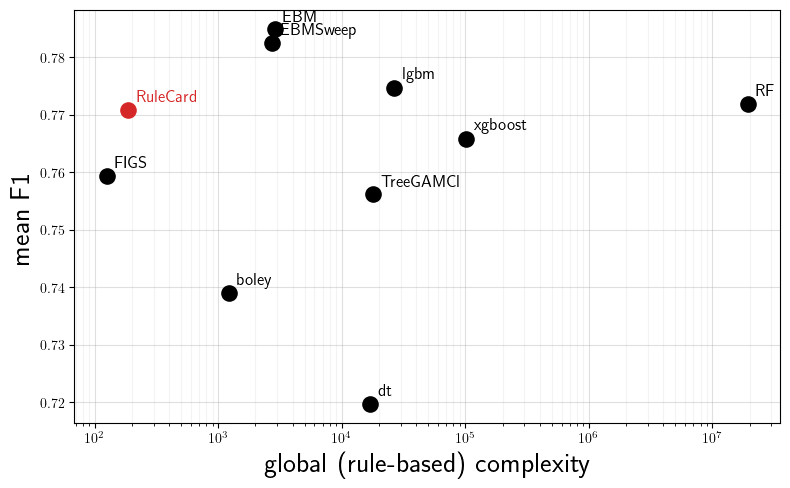

In [935]:
fig, ax = plt.subplots(figsize=(8, 5))

highlight = "RuleCard"

df_plot = df_best.dropna(subset=['global', 'local'], axis=0).groupby('model_name')[['f1_macro', 'global', 'local']].mean()

for model, row in df_plot[df_plot.f1_macro > .5].iterrows():
    color = "tab:red" if model == highlight else "black"

    ax.scatter(row["global"], row["f1_macro"], s=120, color=color, zorder=3)

    ax.annotate(model, (row["global"], row["f1_macro"]), xytext=(6, 6), textcoords="offset points", fontsize=12, color=color,)

ax.set_xscale("log")
#ax.invert_xaxis()
ax.set_xlabel("global (rule-based) complexity", fontsize=20)
ax.set_ylabel("mean F1", fontsize=20)

ax.grid(True, which="major", alpha=0.4)
ax.grid(True, which="minor", alpha=0.15)

plt.tight_layout()
plt.show()

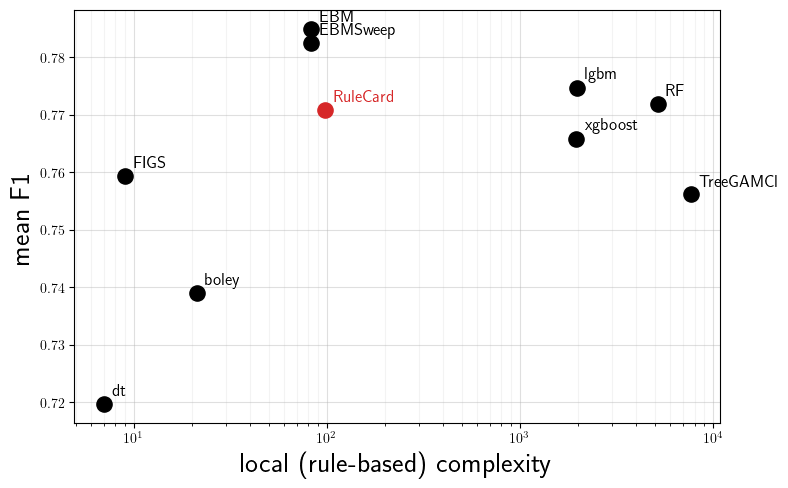

In [936]:
fig, ax = plt.subplots(figsize=(8, 5))

highlight = "RuleCard"

df_plot = df_best.dropna(subset=['global', 'local'], axis=0).groupby('model_name')[['f1_macro', 'global', 'local']].mean()

for model, row in df_plot[df_plot.f1_macro > .5].iterrows():
    color = "tab:red" if model == highlight else "black"

    ax.scatter(row["local"], row["f1_macro"], s=120, color=color, zorder=3)

    ax.annotate(model, (row["local"], row["f1_macro"]), xytext=(6, 6), textcoords="offset points", fontsize=12, color=color,)

ax.set_xscale("log")
#ax.invert_xaxis()
ax.set_xlabel("local (rule-based) complexity", fontsize=20)
ax.set_ylabel("mean F1", fontsize=20)

ax.grid(True, which="major", alpha=0.4)
ax.grid(True, which="minor", alpha=0.15)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'global (rule-based) complexity')

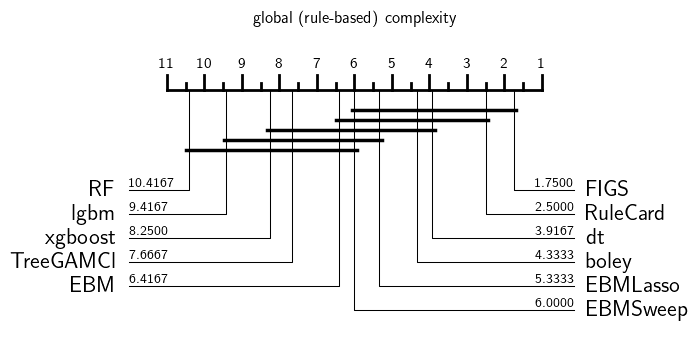

In [937]:
df_cd = df_best.dropna(subset=['global', 'local'], axis=0).pivot(columns='model_name', index='dataset_name', values='global').copy()


fig, ax = plot_critical_difference(df_cd.values, labels=df_cd.columns, lower_better=True, test='nemenyi', alpha=.05)
ax.set_title('global (rule-based) complexity')

Text(0.5, 1.0, 'local (rule-based) complexity')

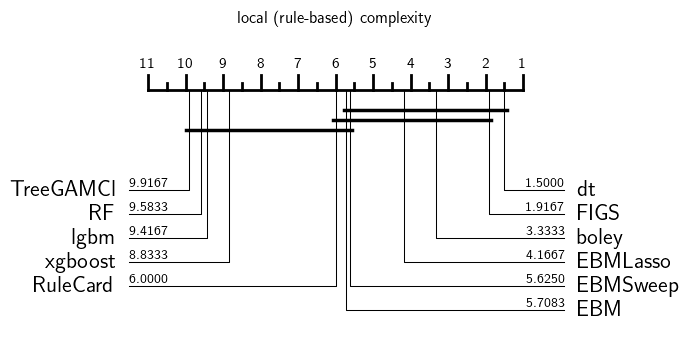

In [938]:
df_cd = df_best.dropna(subset=['global', 'local'], axis=0).pivot(columns='model_name', 
                                                                 index='dataset_name', 
                                                                 values='local').copy()

fig, ax = plot_critical_difference(df_cd.values, labels=df_cd.columns, lower_better=True, 
                                   test='nemenyi', alpha=.05)
ax.set_title('local (rule-based) complexity')

## Feature Importance

In [939]:
df_best = df[~df.model_name.isin(['ScoreCard', 'ScoreCard2', 'ScoreCard3'])].sort_values(by=['dataset_name', 'model_name', 'val_f1_score'], ascending=[False, False, False])\
    .groupby(['dataset_name', 'model_name']).first().reset_index()

print(df_best.shape)
df_best.head()

(221, 109)


,dataset_name,model_name,learning_rate,patience,max_depth,max_n_iter,feature_order,recompute_feature_order,reuse_features,use_fast,...,l1_ratio,dual,num_rules,rfmode,max_rules,memory_par,model_type,max_trees,min_impurity_decrease,max_features
0,adult,EBM,0.05,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
1,adult,EBMLasso,0.01,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
2,adult,EBMSweep,0.01,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN
3,adult,FIGS,NaN,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,48.0,NaN,None,NaN,0.0,NaN
4,adult,LogisticGAM,NaN,NaN,NaN,NaN,None,None,None,None,...,NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN


In [940]:
from kneed import KneeLocator
from scipy.special import softmax

def _get_top_idx_score(scores, thr_feat_imp): #80% score
    scores = np.abs(np.array(scores))
    idx_sorted = np.argsort(scores)[::-1]
    scores_sorted = scores[idx_sorted]
    cum = np.cumsum(scores_sorted)
    selected_idx = idx_sorted[cum <= thr_feat_imp*scores_sorted.sum()]
    return selected_idx

def __get_top_idx_score(scores, thr_feat_imp): #percentile
    scores = np.abs(np.array(scores))

    threshold = np.quantile(scores, 1-thr_feat_imp)
    return np.where(scores > threshold)[0]

def __get_top_idx_score(scores, thr_feat_imp): #knee
    scores = np.abs(np.array(scores))
    idx_sorted = np.argsort(scores)[::-1]
    sorted_scores = scores[idx_sorted]

    cum = np.cumsum(sorted_scores) / (np.sum(sorted_scores) + 1e-12)

    k = KneeLocator(np.arange(len(cum)), cum, curve="concave", direction="increasing")

    knee = k.knee
    if knee is None:
        return idx_sorted

    return idx_sorted[:knee + 1]

def get_top_idx_score(scores, thr_feat_imp): #non-zero
    #return np.where(scores > threshold)[0]
    return np.where(scores != .0)[0]

def explain_ebm_fi(ebm, X=None, thr_feat_imp=.8):
    thr_feat_imp = -1
    exp = ebm.explain_global().data()
    gl = 0
    lo = 0
    bins_features = {f'feature_{i:04d}': [len(x_) + 1 for x_ in x] for i, x in enumerate(ebm.bins_)}

    for feat_name, feat_score in zip(exp['names'], exp['scores']):
        if np.abs(feat_score) <= thr_feat_imp:
            continue

        if '&' in feat_name:
            feat_name_split = feat_name.split(' & ')
            gl += bins_features[feat_name_split[0]][0] * bins_features[feat_name_split[1]][0]
        else:
            gl += bins_features[feat_name][0]
        lo += 1

    return gl, lo

def explain_ebm_lasso_fi(ebm, X=None, thr_feat_imp=.8):
    return explain_ebm_fi(ebm.ebm_, X, thr_feat_imp)

def explain_logisticReg(lreg, X, thr_feat_imp=.8):
    top_glo = get_top_idx_score(lreg.coef_[0], thr_feat_imp)
    top_loc = np.mean([len(get_top_idx_score((lreg.coef_ * X[i]).sum(axis=0), thr_feat_imp)) for i in range(X.shape[0])])

    return len(top_glo), top_loc

def explain_ridge(ridge, X, thr_feat_imp=.8):
    top_glo = get_top_idx_score(ridge.coef_, thr_feat_imp)
    top_loc = np.mean([len(get_top_idx_score((ridge.coef_ * X[i]), thr_feat_imp)) for i in range(X.shape[0])])

    return len(top_glo), top_loc

def explain_scorecard_fi(sc, X=None, thr_feat_imp=.8):
    new_scorecard = []
    scorecard = ScoreCard.from_rulecard(sc, X)
    for i in range(len(scorecard.scorecard)):
        new_scorecard += [tuple([scorecard.scorecard[i][0], compress_rules(scorecard.scorecard[i][1]), *scorecard.scorecard[i][2:]])]
    
    glo = len(new_scorecard)
    lo = np.mean(np.vstack([_get_activation(X, rules) for _, rules, _, _ in new_scorecard]).sum(axis=0))

    return glo, lo

def explain_alogisticReg(lreg, X, thr_feat_imp=.8):
    top_glo = get_top_idx_score(lreg.clf.coef_[0], thr_feat_imp)
    X_enc = lreg._encode(pd.DataFrame(X, columns=[f'feat_{i}' for i in tqdm(range(X.shape[1]))]).infer_objects())
    top_loc = np.mean([len(get_top_idx_score((lreg.clf.coef_ * X_enc[i]).sum(axis=0), thr_feat_imp)) 
                       for i in tqdm(range(X_enc.shape[0]))])

    return len(top_glo), top_loc

def explain_aridge(ridge, X, thr_feat_imp=.8):
    top_glo = get_top_idx_score(ridge.clf.coef_, thr_feat_imp)
    X_enc = ridge._encode(pd.DataFrame(X, columns=[f'feat_{i}' for i in tqdm(range(X.shape[1]))]).infer_objects())
    top_loc = np.mean([len(get_top_idx_score((ridge.clf.coef_ * X_enc[i]), thr_feat_imp)) for i in tqdm(range(X.shape[0]))])

    return len(top_glo), top_loc

def explain_rfit(rfit, X=None, thr_feat_imp=.8):
    gl = len(get_top_idx_score(rfit.coef_, thr_feat_imp))

    X_concat = np.zeros((X.shape[0], 0))

    if "l" in rfit.model_type:
        if rfit.lin_standardise:
            X_concat = np.concatenate((X_concat, rfit.friedscale.scale(X)), axis=1)
        else:
            X_concat = np.concatenate((X_concat, X), axis=1)

    if "r" in rfit.model_type:
        rule_coefs = rfit.coef_[-len(rfit.rule_ensemble.rules):]
        X_rules = rfit.rule_ensemble.transform(X, coefs=rule_coefs)
        X_concat = np.concatenate((X_concat, X_rules), axis=1)

    lo_score = X_concat * rfit.coef_
    lo = np.mean([len(get_top_idx_score(lo_score[i], thr_feat_imp)) for i in range(X.shape[0])])

    return gl, lo

def explain_lgam(lgam, X=None, thr_feat_imp=.8):
    gl = len(get_top_idx_score(np.abs(lgam.coef_)[:-1], thr_feat_imp))
    lo_score = lgam._modelmat(X_train).todense()
    lo = np.mean([len(get_top_idx_score(lo_score[i], thr_feat_imp)) for i in range(lo_score.shape[0])])

    return gl, lo


In [978]:
import pickle

expl_fun_fi = {
    'EBM': explain_ebm_fi,
    'EBMSweep': explain_ebm_fi,
    'EBMLasso': explain_ebm_lasso_fi,
    'log_reg': explain_logisticReg,
    'ridge': explain_ridge,
    'RuleCard': explain_scorecard_fi,
    'rulefit': explain_rfit, #no predict proba
    'LogisticGAM': explain_lgam,
    'apriori_log': None,#explain_alogisticReg,
    'apriori_ridge': None#explain_aridge
}

expl = []

for filename, model_name in tqdm(df_best[['filename', 'model_name']].values):    
    if model_name not in expl_fun_fi:
        expl.append([None]*6)
        continue
    
    X_train, y_train, X_test, y_test = load_data(filename.replace('.csv', '.h5')) 
    with open(filename.replace('.csv', '.pkl'), 'rb') as f:
        clf = pickle.load(f)

    try:
        if model_name == 'boley':
            df_boley = pd.DataFrame(X_test, columns=[f'feat{i}' for i in range(X_test.shape[1])])
            y_pred = clf.predict_proba(df_boley)
        else:
            if model_name == 'ridge':
                y_pred = softmax(clf.decision_function(X_test))
            elif model_name == 'log_reg':
                y_pred = clf._predict_proba_lr(X_test)
            elif model_name == 'apriori_log':
                X_cod = clf._encode(
                    pd.DataFrame(X_test, columns=[f'feat_{i}' for i in range(X_test.shape[1])])\
                    .infer_objects())
                y_pred = clf.clf.predict_proba(X_cod)
            elif model_name == 'apriori_ridge':
                X_cod = clf._encode(
                    pd.DataFrame(X_test, columns=[f'feat_{i}' for i in range(X_test.shape[1])])\
                    .infer_objects())
                y_pred = softmax(clf.clf.decision_function(X_cod))
            else:
                y_pred = clf.predict_proba(X_test)
                
        y_pred_ = y_pred if len(y_pred.shape) == 1 else y_pred[:, 0]
        additional = [x[1] for x in calibration_metrics(y_true=y_test, y_prob=y_pred_, n_bins=10, return_curve=False)]
    except Exception as e:
        print(f'{model_name}: {e}')
        additional = [None]*4
        

    e = list(expl_fun_fi[model_name](clf, np.vstack([X_train, X_test]), thr_feat_imp=10**-9))
    #print(type(clf), e)
    expl.append(e+additional)

  0%|          | 0/221 [00:00<?, ?it/s]

rulefit: 'RuleFit' object has no attribute 'predict_proba'


TypeError: 'NoneType' object is not callable

In [983]:
top_glo = get_top_idx_score(clf.clf.coef_[0], -1)
X_enc = clf._encode(pd.DataFrame(X_test, columns=[f'feat_{i}' for i in tqdm(range(X_test.shape[1]))]).infer_objects())
top_loc = np.mean([len(get_top_idx_score((clf.clf.coef_ * X_enc[i]).sum(axis=0), -1)) 
                   for i in tqdm(range(X_enc.shape[0]))])

len(top_glo), top_loc

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/30000 [00:00<?, ?it/s]

(39, 0.0)

In [985]:
for i in tqdm(range(X_enc.shape[0])):
    print(get_top_idx_score((clf.clf.coef_ * X_enc[i]).sum(axis=0), -1))
    break

  0%|          | 0/30000 [00:00<?, ?it/s]

[]


In [987]:
clf.clf.coef_

array([[-0.03113097, -0.03113097, -0.03113097, -0.03113097, -0.01511548,
        -0.01511548, -0.01511548, -0.01511548,  0.03773635,  0.03773635,
         0.03773635,  0.03773635, -0.04225923, -0.04225923, -0.04225923,
        -0.04225923, -0.0246268 , -0.0246268 , -0.0246268 , -0.0246268 ,
        -0.47762366, -0.47762366, -0.47762366, -0.47762366, -0.10839835,
        -0.10839835, -0.10839835, -0.10839835, -0.06884875, -0.06884875,
        -0.06884875, -0.06884875,  0.0287982 ,  0.0287982 ,  0.0287982 ,
         0.0287982 , -0.22834757, -0.22834757, -0.22834757]])

In [1009]:
from Experiments.apriori_reg import AprioriReg

#np.sum(clf._encode(pd.DataFrame(X_train, columns=[f'feat_{i}' 
#                                                  for i in tqdm(range(X_test.shape[1]))]).infer_objects()))

def preprocess(X:np.ndarray, y:np.ndarray, q):
    df = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(X.shape[1])]).infer_objects()
    for col in df.columns:
        df[col] = pd.qcut(df[col], q).apply(lambda x: f'{x}|{col}')
    return df.values, y

preprocess(np.vstack([X_train, X_test]), np.hstack([y_train, y_test]), clf.quantiles)

ValueError: Bin edges must be unique: Index([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 98.0], dtype='float64', name='feat_1').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [1004]:
np.hstack([y_train, y_test])

array([0, 0, 0, ..., 0, 0, 0])

In [943]:
df_best[['fi_global', 'fi_local']] = np.array(expl)[:, :2]

In [944]:
df_best.dropna(subset=['fi_global', 'fi_local',], axis=0).groupby('model_name')[['f1_score', "accuracy", 'fi_global', 'fi_local', 'roc_micro']]\
    .agg(['mean', 'std']).round(3).to_csv('expl_and_calib_fi.csv')

In [945]:
df_best.dropna(subset=['fi_global'], axis=0).groupby('model_name')[['f1_score', 'fi_global', 'fi_local']].median().round(4)

,f1_score,fi_global,fi_local
model_name,,,
EBM,0.6990,81926.0,40.0
EBMLasso,0.5704,42648.0,20.5
EBMSweep,0.6986,58418.5,40.0
LogisticGAM,0.6784,360.0,65.656272
RuleCard,0.6758,147.5,96.818956
apriori_log,0.5385,62.0,0.0
apriori_ridge,0.5192,36.0,0.0
log_reg,0.6610,18.0,9.191506
ridge,0.6656,18.0,9.191506


In [946]:
df_best[df_best.model_name == 'RuleCard'][['f1_score', "accuracy", 'fi_global', 'fi_local', 'roc_micro']]

,f1_score,accuracy,fi_global,fi_local,roc_micro
6,0.692392,0.862467,128,86.828374,0.915581
23,0.226248,0.935933,39,35.278873,0.851128
41,0.762626,0.765000,198,137.9845,0.829913
60,0.975610,0.982456,346,197.629174,0.991402
79,0.659266,0.723493,145,106.809537,0.790328
98,0.627451,0.753247,107,71.359375,0.823426
117,0.563107,0.775000,256,150.932,0.793571
136,0.753846,0.760000,288,158.8375,0.853375
155,1.000000,1.000000,150,109.815854,1.000000
172,0.491642,0.827667,81,55.031,0.773138


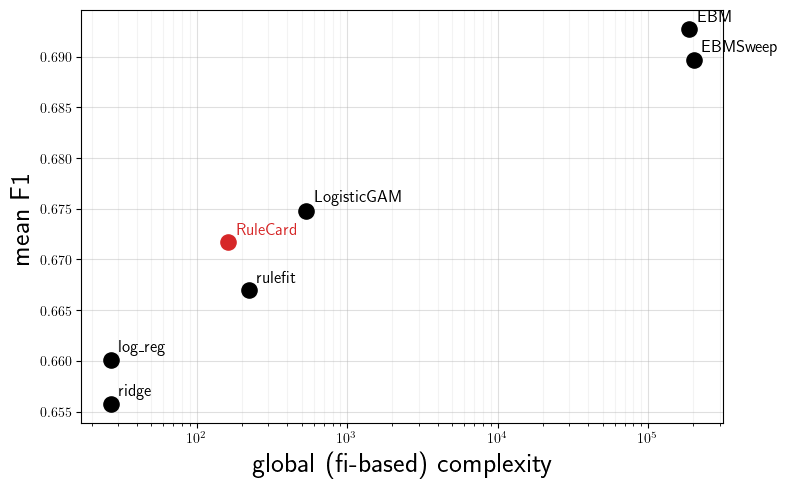

In [947]:
fig, ax = plt.subplots(figsize=(8, 5))

highlight = "RuleCard"

df_plot = df_best.dropna(subset=['fi_global', 'fi_local'], axis=0).groupby('model_name')[['f1_score', 'fi_global', 'fi_local']].mean()

for model, row in df_plot[df_plot.f1_score > .6].iterrows():
    color = "tab:red" if model == highlight else "black"

    ax.scatter(row["fi_global"], row["f1_score"], s=120, color=color, zorder=3)

    ax.annotate(model, (row["fi_global"], row["f1_score"]), xytext=(6, 6), textcoords="offset points", fontsize=12, color=color,)

ax.set_xscale("log")
#ax.invert_xaxis()
ax.set_xlabel("global (fi-based) complexity", fontsize=20)
ax.set_ylabel("mean F1", fontsize=20)

ax.grid(True, which="major", alpha=0.4)
ax.grid(True, which="minor", alpha=0.15)

plt.tight_layout()
plt.show()

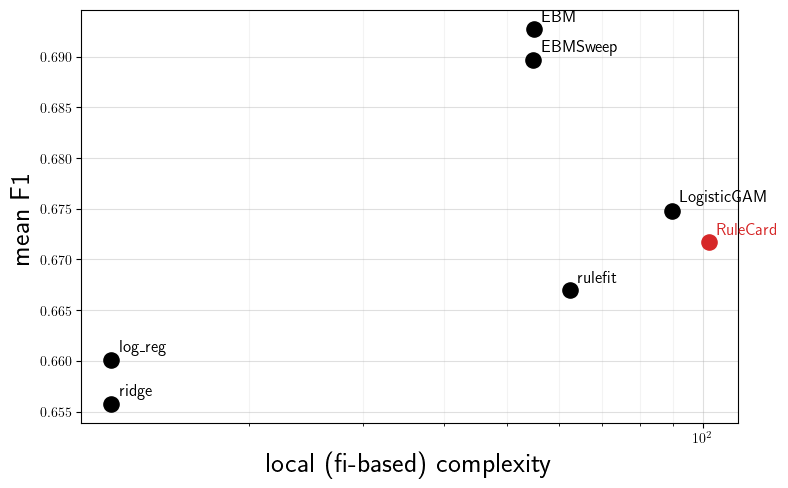

In [948]:
fig, ax = plt.subplots(figsize=(8, 5))

highlight = "RuleCard"

df_plot = df_best.dropna(subset=['fi_global', 'fi_local'], axis=0).groupby('model_name')[['f1_score', 'fi_global', 'fi_local']].mean()

for model, row in df_plot[df_plot.f1_score > .6].iterrows():
    color = "tab:red" if model == highlight else "black"

    ax.scatter(row["fi_local"], row["f1_score"], s=120, color=color, zorder=3)

    ax.annotate(model, (row["fi_local"], row["f1_score"]), xytext=(6, 6), textcoords="offset points", fontsize=12, color=color,)

ax.set_xscale("log")
#ax.invert_xaxis()
ax.set_xlabel("local (fi-based) complexity", fontsize=20)
ax.set_ylabel("mean F1", fontsize=20)

ax.grid(True, which="major", alpha=0.4)
ax.grid(True, which="minor", alpha=0.15)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'global (fi-based) complexity')

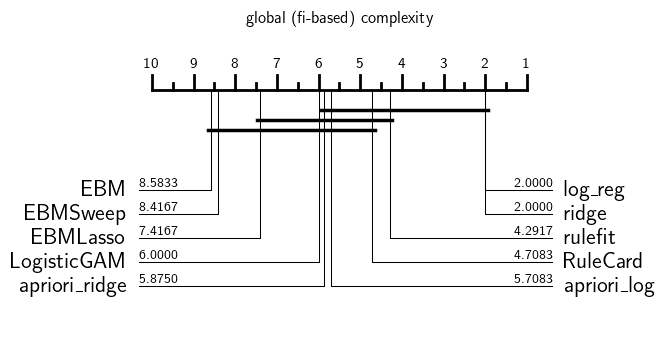

In [949]:
df_cd = df_best.dropna(subset=['fi_global', 'fi_local'], axis=0).pivot(columns='model_name', index='dataset_name', values='fi_global').copy().fillna(10**7)


fig, ax = plot_critical_difference(df_cd.values, labels=df_cd.columns, lower_better=True, test='nemenyi', alpha=.05)
ax.set_title('global (fi-based) complexity')

Text(0.5, 1.0, 'local (fi-based) complexity')

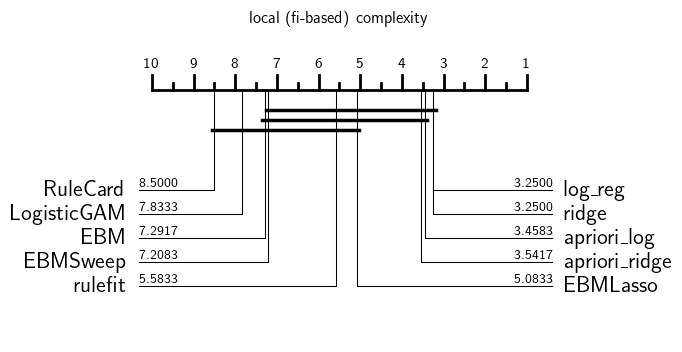

In [950]:
df_cd = df_best.dropna(subset=['fi_global', 'fi_local'], axis=0).pivot(columns='model_name', index='dataset_name', values='fi_local').copy().fillna(10**7)


fig, ax = plot_critical_difference(df_cd.values, labels=df_cd.columns, lower_better=True, test='nemenyi', alpha=.05)
ax.set_title('local (fi-based) complexity')

## Both

In [965]:
len(expl_rule)

221

In [966]:
len(expl)

221

In [967]:
expl_rule[:2]

[[3755,
  238,
  0.7421548798754966,
  3.8947629400189983,
  0.7508688963944941,
  0.9787742394048436],
 [620,
  55,
  0.26834010742139797,
  0.7339398021723378,
  0.38336766141948797,
  0.7365579798255409]]

In [968]:
exp_all = []

for score_fi, score_rb in zip(expl, expl_rule):
    exp_all += [{
        'fi_global': score_fi[0],
        'fi_local': score_fi[1],
        'rb_global': score_rb[0],
        'rb_local': score_rb[1],
        
        'brier_score': score_fi[2] if score_fi[2] is not None else score_rb[2],
        'log_loss': score_fi[3] if score_fi[3] is not None else score_rb[3],
        'ece': score_fi[4] if score_fi[4] is not None else score_rb[4],
        'mce': score_fi[5] if score_fi[5] is not None else score_rb[5],
        
    }]

df_expl_calib = pd.DataFrame(exp_all)

df_expl_calib.head(2)

,fi_global,fi_local,rb_global,rb_local,brier_score,log_loss,ece,mce
0,36134.0,136.0,3755.0,238.0,0.742155,3.894763,0.750869,0.978774
1,12578.0,39.0,620.0,55.0,0.268340,0.733940,0.383368,0.736558


In [969]:
df_best[df_expl_calib.columns] = df_expl_calib

In [970]:
df_best.groupby('model_name')[['f1_score', 'fi_global', 'fi_local', 'rb_global', 'rb_local']].agg(['mean'])\
    .sort_index(key=lambda x: x.str.lower()).round(2)

,f1_score,fi_global,fi_local,rb_global,rb_local
,mean,mean,mean,mean,mean
model_name,,,,,
apriori_log,0.49,203585.56,0.00,NaN,NaN
apriori_ridge,0.44,196684.67,0.11,NaN,NaN
boley,0.63,NaN,NaN,1210.08,21.20
dt,0.58,NaN,NaN,16776.17,7.00
EBM,0.69,188587.58,54.92,2871.33,83.08
EBMLasso,0.54,389959.42,23.67,2573.42,32.92
EBMSweep,0.69,201152.08,54.83,2734.42,83.00
fasterrisk,0.52,NaN,NaN,NaN,NaN


In [971]:
df_fasterrisk = pd.read_csv('res_fasterrisk.csv').set_index('filename')

df_fasterrisk_dict = df_fasterrisk.to_dict(orient='index')

In [972]:
def foo(x):
    if x.filename in df_fasterrisk_dict and 'fasterrisk' in x.model_name:
        d = df_fasterrisk_dict[x.filename]
        return (
            d['fi_global'],
            d['fi_local'],
            d['fi_global'],
            d['fi_local'],
            d['brier_score'],
            d['log_loss'],
            d['ece'],
            d['mce'],
        )
    return x[['fi_global', 'fi_local', 'rb_global', 'rb_local', 'brier_score', 'log_loss', 'ece', 'mce']]

df_best[['fi_global', 'fi_local', 'rb_global', 'rb_local', 'brier_score', 'log_loss', 'ece', 'mce']] = df_best.apply(foo, axis=1)

In [973]:
df_best.groupby('model_name')[['f1_score', "accuracy", 'roc_micro', 'brier_score', 
                               'log_loss', 'ece']].agg(['mean', 'std'])\
    .sort_index(key=lambda x: x.str.lower()).round(2)

f1_score       accuracy       roc_micro       brier_score        \
                  mean   std     mean   std      mean   std        mean   std   
model_name                                                                      
apriori_log       0.49  0.21     0.45  0.20       NaN   NaN        0.25  0.03   
apriori_ridge     0.44  0.24     0.38  0.17       NaN   NaN        0.35  0.14   
boley             0.63  0.24     0.81  0.10      0.82  0.09         NaN   NaN   
dt                0.58  0.27     0.80  0.10      0.80  0.10        0.67  0.17   
EBM               0.69  0.19     0.84  0.09      0.87  0.07        0.68  0.18   
EBMLasso          0.54  0.16     0.47  0.12      0.86  0.07        0.29  0.04   
EBMSweep          0.69  0.19     0.84  0.09      0.87  0.07        0.68  0.18   
fasterrisk        0.52  0.32     0.71  0.17      0.77  0.14        0.21  0.15   
fasterriskBin     0.64  0.19     0.82  0.10      0.83  0.10        0.13  0.07   
FIGS              0.66  0.18     0.82  0.09      0.83  0.08        0.41  0.06   
lgbm              0.68  0.19     0.83  0.09      0.86  0.08        0.70  0.16   
log_reg           0.66  0.18     0.78  0.10      0.83  0.10        0.53  0.20   
LogisticGAM       0.67  0.20     0.83  0.09      0.86  0.08        0.12  0.06   
RF                0.67  0.20     0.83  0.09      0.86  0.08        0.63  0.19   
ridge             0.66  0.19     0.77  0.10       NaN   NaN        0.34  0.13   
RuleCard          0.67  0.21     0.83  0.09      0.86  0.07        0.12  0.06   
rulefit           0.67  0.19     0.83  0.10      0.84  0.09         NaN   NaN   
TreeGAMCl         0.65  0.21     0.82  0.09      0.86  0.07        0.60  0.19   
xgboost           0.67  0.19     0.82  0.10      0.85  0.08        0.65  0.16   

              log_loss          ece        
                  mean    std  mean   std  
model_name                                 
apriori_log       0.69   0.07  0.14  0.14  
apriori_ridge     2.11   0.83  0.35  0.14  
boley              NaN    NaN   NaN   NaN  
dt                9.71  12.01  0.67  0.18  
EBM               5.15   7.10  0.69  0.17  
EBMLasso          0.78   0.09  0.36  0.10  
EBMSweep          5.14   7.09  0.69  0.17  
fasterrisk        0.71   0.64  0.17  0.17  
fasterriskBin     0.43   0.19  0.05  0.04  
FIGS              1.03   0.13  0.49  0.12  
lgbm              5.01   4.97  0.71  0.16  
log_reg           2.28   2.22  0.56  0.19  
LogisticGAM       0.38   0.19  0.04  0.03  
RF                6.83   9.80  0.65  0.19  
ridge             2.13   0.80  0.34  0.13  
RuleCard          0.37   0.18  0.03  0.03  
rulefit            NaN    NaN   NaN   NaN  
TreeGAMCl         6.16   5.64  0.62  0.19  
xgboost           3.05   1.64  0.68  0.13

In [974]:
df_best.model_name.unique()

array(['EBM', 'EBMLasso', 'EBMSweep', 'FIGS', 'LogisticGAM', 'RF',
       'RuleCard', 'TreeGAMCl', 'boley', 'dt', 'fasterrisk',
       'fasterriskBin', 'lgbm', 'log_reg', 'ridge', 'rulefit', 'xgboost',
       'apriori_log', 'apriori_ridge'], dtype=object)

In [975]:
df_best.groupby('model_name')[['f1_score', 'fi_global', 'fi_local', 'rb_global', 'rb_local']].agg(['mean'])\
    .sort_index(key=lambda x: x.str.lower()).round(2)

,f1_score,fi_global,fi_local,rb_global,rb_local
,mean,mean,mean,mean,mean
model_name,,,,,
apriori_log,0.49,203585.56,0.00,NaN,NaN
apriori_ridge,0.44,196684.67,0.11,NaN,NaN
boley,0.63,NaN,NaN,1210.08,21.20
dt,0.58,NaN,NaN,16776.17,7.00
EBM,0.69,188587.58,54.92,2871.33,83.08
EBMLasso,0.54,389959.42,23.67,2573.42,32.92
EBMSweep,0.69,201152.08,54.83,2734.42,83.00
fasterrisk,0.52,7.36,2.24,7.36,2.24


In [976]:
df_best[df_best.model_name == 'RuleCard'][['f1_score', 'fi_global', 'fi_local', 'rb_global', 'rb_local']]

,f1_score,fi_global,fi_local,rb_global,rb_local
6,0.692392,128.0,86.828374,168.0,96.779771
23,0.226248,39.0,35.278873,30.0,26.278873
41,0.762626,198.0,137.984500,175.0,114.984500
60,0.975610,346.0,197.629174,427.0,208.414763
79,0.659266,145.0,106.809537,184.0,124.941364
98,0.627451,107.0,71.359375,140.0,79.878906
117,0.563107,256.0,150.932000,303.0,142.203000
136,0.753846,288.0,158.837500,313.0,125.055500
155,1.000000,150.0,109.815854,169.0,106.088134
172,0.491642,81.0,55.031000,84.0,44.495233


In [977]:
df_best.to_csv('df_best_final_all_metrics.csv', index=None)